# 02 — Model experiments

Compares the logged experiments (guide §19). All numbers are read from `reports/metrics/`, which is written by `make train`, `make tune`, `make evaluate`, `make transformer` and `make domain-eval`; nothing here is typed in by hand.

- **fs1** = the guide's word TF-IDF; **fs2** = word TF-IDF with emoji/punctuation tokens + character n-grams; **transformer** = DistilBERT (E4).
- E1–E4 are scored on **validation**. `E3-final` / `E4-final` use the test set once per model version.
- The Mentor-domain eval set (`data/mentor_eval/`) measures what matters for the app.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from src import config

experiments = pd.read_csv(config.EXPERIMENTS_CSV)
experiments["run"] = experiments["id"] + " / " + experiments["features"]
experiments

,id,timestamp,label_map,features,model,settings,eval_split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cv_macro_f1,purpose,run
0,E1,2026-09-14T19:11:30+00:00,v2,fs1,logreg,"TF-IDF ngram=(1, 2) min_df=2 max_df=0.95 subli...",validation,0.7312,0.6198,0.6871,0.6483,0.7360,NaN,Baseline,E1 / fs1
1,E2,2026-09-14T19:11:32+00:00,v2,fs1,linear_svm,"TF-IDF ngram=(1, 2) min_df=2 max_df=0.95 subli...",validation,0.7502,0.6833,0.6635,0.6722,0.7487,NaN,Comparison,E2 / fs1
2,E3,2026-09-14T19:13:35+00:00,v2,fs1,linear_svm,"TF-IDF ngram=(1, 2) min_df=1 max_df=0.95 subli...",validation,0.7681,0.7059,0.6886,0.6962,0.7665,0.6356,Best candidate (tuned),E3 / fs1
3,E3-cal,2026-09-14T19:13:39+00:00,v2,fs1,linear_svm_calibrated,"TF-IDF ngram=(1, 2) min_df=1 max_df=0.95 subli...",validation,0.7705,0.7648,0.6418,0.6920,0.7636,0.6356,Best candidate with calibrated probabilities,E3-cal / fs1
4,E3-final,2026-09-14T19:15:22+00:00,v2,fs1,linear_svm_calibrated,"TF-IDF ngram=(1, 2) min_df=1 max_df=0.95 subli...",test,0.7668,0.7481,0.6238,0.6720,0.7562,0.6356,Final model (single test evaluation),E3-final / fs1
5,E1,2026-09-14T19:29:50+00:00,v2,fs2,logreg,"fs2: word TF-IDF ngram=(1, 2) min_df=2 max_df=...",validation,0.7499,0.6510,0.7071,0.6745,0.7550,NaN,Baseline,E1 / fs2
6,E2,2026-09-14T19:29:58+00:00,v2,fs2,linear_svm,"fs2: word TF-IDF ngram=(1, 2) min_df=2 max_df=...",validation,0.7672,0.7195,0.6788,0.6972,0.7655,NaN,Comparison,E2 / fs2
7,E3,2026-09-14T19:35:02+00:00,v2,fs2,linear_svm,"fs2: word TF-IDF ngram=(1, 2) min_df=1 max_df=...",validation,0.7800,0.7154,0.7160,0.7149,0.7783,0.6629,Best candidate (tuned),E3 / fs2
8,E3-cal,2026-09-14T19:35:11+00:00,v2,fs2,linear_svm_calibrated,"fs2: word TF-IDF ngram=(1, 2) min_df=1 max_df=...",validation,0.7895,0.7803,0.6395,0.6954,0.7816,0.6629,Best candidate with calibrated probabilities,E3-cal / fs2
9,E3-final,2026-09-14T19:47:48+00:00,v2,fs2,linear_svm_calibrated,"fs2: word TF-IDF ngram=(1, 2) min_df=1 max_df=...",test,0.7794,0.7357,0.6542,0.6862,0.7718,0.6629,Final model (single test evaluation),E3-final / fs2


## Headline metrics per experiment

,model,eval_split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cv_macro_f1
run,,,,,,,,
E1 / fs1,logreg,validation,0.7312,0.6198,0.6871,0.6483,0.7360,NaN
E2 / fs1,linear_svm,validation,0.7502,0.6833,0.6635,0.6722,0.7487,NaN
E3 / fs1,linear_svm,validation,0.7681,0.7059,0.6886,0.6962,0.7665,0.6356
E3-cal / fs1,linear_svm_calibrated,validation,0.7705,0.7648,0.6418,0.6920,0.7636,0.6356
E3-final / fs1,linear_svm_calibrated,test,0.7668,0.7481,0.6238,0.6720,0.7562,0.6356
E1 / fs2,logreg,validation,0.7499,0.6510,0.7071,0.6745,0.7550,NaN
E2 / fs2,linear_svm,validation,0.7672,0.7195,0.6788,0.6972,0.7655,NaN
E3 / fs2,linear_svm,validation,0.7800,0.7154,0.7160,0.7149,0.7783,0.6629
E3-cal / fs2,linear_svm_calibrated,validation,0.7895,0.7803,0.6395,0.6954,0.7816,0.6629


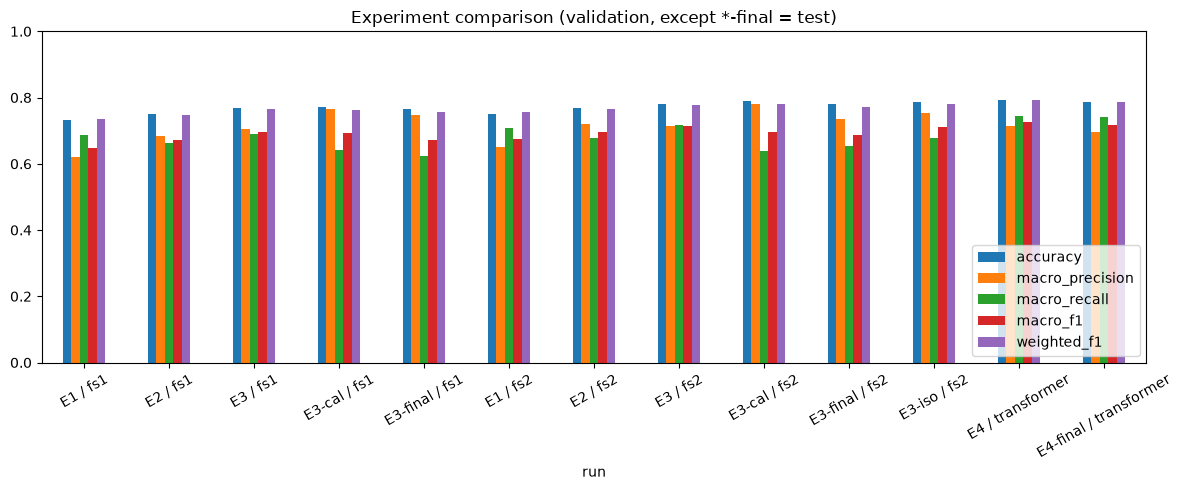

In [2]:
latest = experiments.drop_duplicates(subset=["run", "eval_split"], keep="last").set_index("run")
metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]

fig, ax = plt.subplots(figsize=(12, 5))
latest[metric_cols].plot.bar(ax=ax, rot=30)
ax.set_ylim(0, 1)
ax.set_title("Experiment comparison (validation, except *-final = test)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(config.FIGURES / "experiment_comparison.png", dpi=200)
latest[["model", "eval_split", *metric_cols, "cv_macro_f1"]]

## Per-class F1 on validation

Macro F1 hides class imbalance; this table shows which Mentor classes are hard.

,E1 / fs2,E1 / fs1,E2 / fs2,E2 / fs1,E3-cal / fs2,E3-cal / fs1,E3-iso / fs2,E3 / fs2,E3 / fs1,E4 / transformer
joy,0.8627,0.8478,0.8629,0.8522,0.8766,0.8583,0.8712,0.8714,0.8672,0.8872
sadness,0.5286,0.5244,0.6270,0.5231,0.5695,0.5789,0.6265,0.6114,0.6010,0.5957
fear_anxiety,0.6447,0.5987,0.6567,0.6277,0.6613,0.6562,0.7015,0.6944,0.6522,0.7310
anger_frustration,0.5829,0.5382,0.5585,0.5361,0.5820,0.5529,0.5765,0.5844,0.5639,0.6421
guilt,0.6774,0.6212,0.6903,0.7009,0.6667,0.7037,0.6957,0.7258,0.6957,0.7559
motivation,0.6402,0.6359,0.6822,0.6780,0.6861,0.6897,0.6852,0.7042,0.6923,0.6650
neutral,0.7848,0.7717,0.8029,0.7876,0.8257,0.8046,0.8202,0.8126,0.8014,0.8159


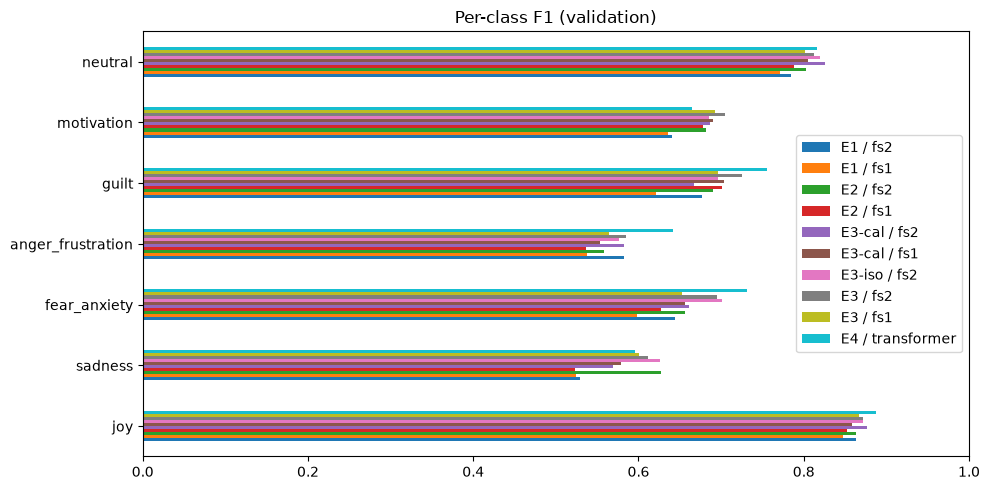

In [3]:
per_class = {}
for path in sorted(config.METRICS.glob("E*_validation.json")):
    report = json.loads(path.read_text())
    key = f"{report['id']} / {report.get('features', 'fs1')}"
    per_class[key] = {
        label: stats["f1-score"]
        for label, stats in report["metrics"]["per_class"].items()
        if isinstance(stats, dict) and "support" in stats and label not in {"macro avg", "weighted avg", "micro avg"}
    }
per_class = pd.DataFrame(per_class)

fig, ax = plt.subplots(figsize=(10, 5))
per_class.plot.barh(ax=ax)
ax.set_xlim(0, 1)
ax.set_title("Per-class F1 (validation)")
fig.tight_layout()
fig.savefig(config.FIGURES / "per_class_f1_validation.png", dpi=200)
per_class.round(4)

## Mentor-domain evaluation set

154 check-in style sentences (`data/mentor_eval/mentor_eval.csv`). This is the acceptance test for the app; GoEmotions scores do not measure it.

,macro_f1,accuracy,acc_emoji,acc_negation,acc_plain,acc_short,labels_reviewed
v2-distilbert-20260914,0.60203,0.590909,0.5,0.6,0.589147,0.714286,False
v2-fs2-linear_svm_calibrated-20260914,0.431126,0.422078,0.125,0.5,0.418605,0.714286,False
v2-linear_svm_calibrated-20260914,0.389177,0.383117,0.125,0.5,0.372093,0.714286,False


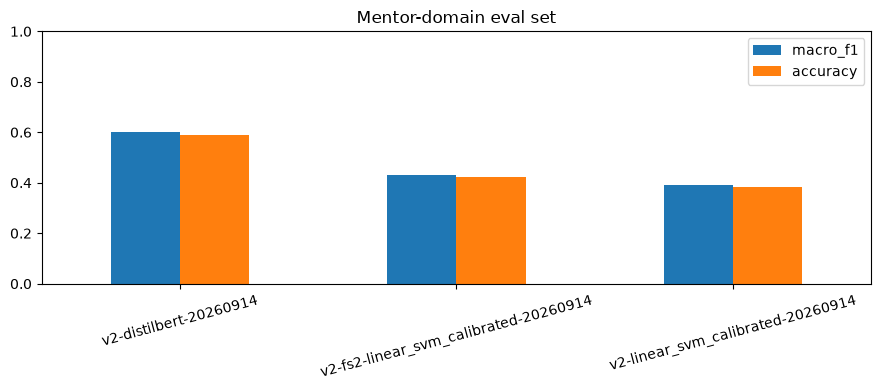

In [4]:
domain = {}
for path in sorted(config.METRICS.glob("domain_eval_*.json")):
    r = json.loads(path.read_text())
    domain[r["model_version"]] = {
        "macro_f1": r["metrics"]["macro_f1"],
        "accuracy": r["metrics"]["accuracy"],
        **{f"acc_{k}": v["accuracy"] for k, v in r["accuracy_by_kind"].items()},
        "labels_reviewed": r["labels_reviewed"],
    }
domain = pd.DataFrame(domain).T
if len(domain):
    fig, ax = plt.subplots(figsize=(9, 4))
    domain[["macro_f1", "accuracy"]].astype(float).plot.bar(ax=ax, rot=15)
    ax.set_ylim(0, 1)
    ax.set_title("Mentor-domain eval set")
    fig.tight_layout()
    fig.savefig(config.FIGURES / "domain_eval_comparison.png", dpi=200)
domain

## Hyperparameter search (cross-validation on train only)

In [5]:
for path in sorted(config.METRICS.glob("E3_*cv_results.csv")):
    print(path.name)
    display(pd.read_csv(path).head(8))

E3_cv_results.csv


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,param_clf,param_clf__C,param_tfidf__ngram_range,param_tfidf__min_df
0,1,0.635563,0.008390,1.795553,LinearSVC,0.5,"(1, 2)",1
1,2,0.629305,0.008435,2.133792,LinearSVC,1.0,"(1, 2)",1
2,3,0.628879,0.008312,1.545379,LinearSVC,0.5,"(1, 1)",1
3,4,0.626169,0.008502,1.144630,LinearSVC,0.5,"(1, 2)",2
4,5,0.621566,0.008750,2.944850,LinearSVC,2.0,"(1, 2)",1
5,6,0.621250,0.007086,0.820155,LinearSVC,0.5,"(1, 1)",2
6,7,0.617487,0.009152,0.866631,LinearSVC,1.0,"(1, 1)",1
7,8,0.616753,0.010023,24.977349,LogisticRegression,2.0,"(1, 2)",1


E3_fs2_cv_results.csv


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,param_clf,param_clf__C,param_features__word__ngram_range,param_features__word__min_df
0,1,0.662861,0.007632,4.133556,LinearSVC,0.25,"(1, 2)",1
1,2,0.661265,0.006028,3.851735,LinearSVC,0.25,"(1, 2)",2
2,3,0.657728,0.004387,4.465911,LinearSVC,0.50,"(1, 2)",1
3,4,0.652143,0.006305,4.213220,LinearSVC,0.50,"(1, 2)",2
4,5,0.647222,0.004484,5.035976,LinearSVC,1.00,"(1, 2)",1
5,6,0.645694,0.006643,35.182543,LogisticRegression,1.00,"(1, 2)",1
6,7,0.645227,0.007725,26.061833,LogisticRegression,1.00,"(1, 2)",2
7,8,0.640677,0.004901,4.695606,LinearSVC,1.00,"(1, 2)",2


## Confusion matrices (row-normalized)

confusion_matrix_E1_fs2_validation_normalized.png


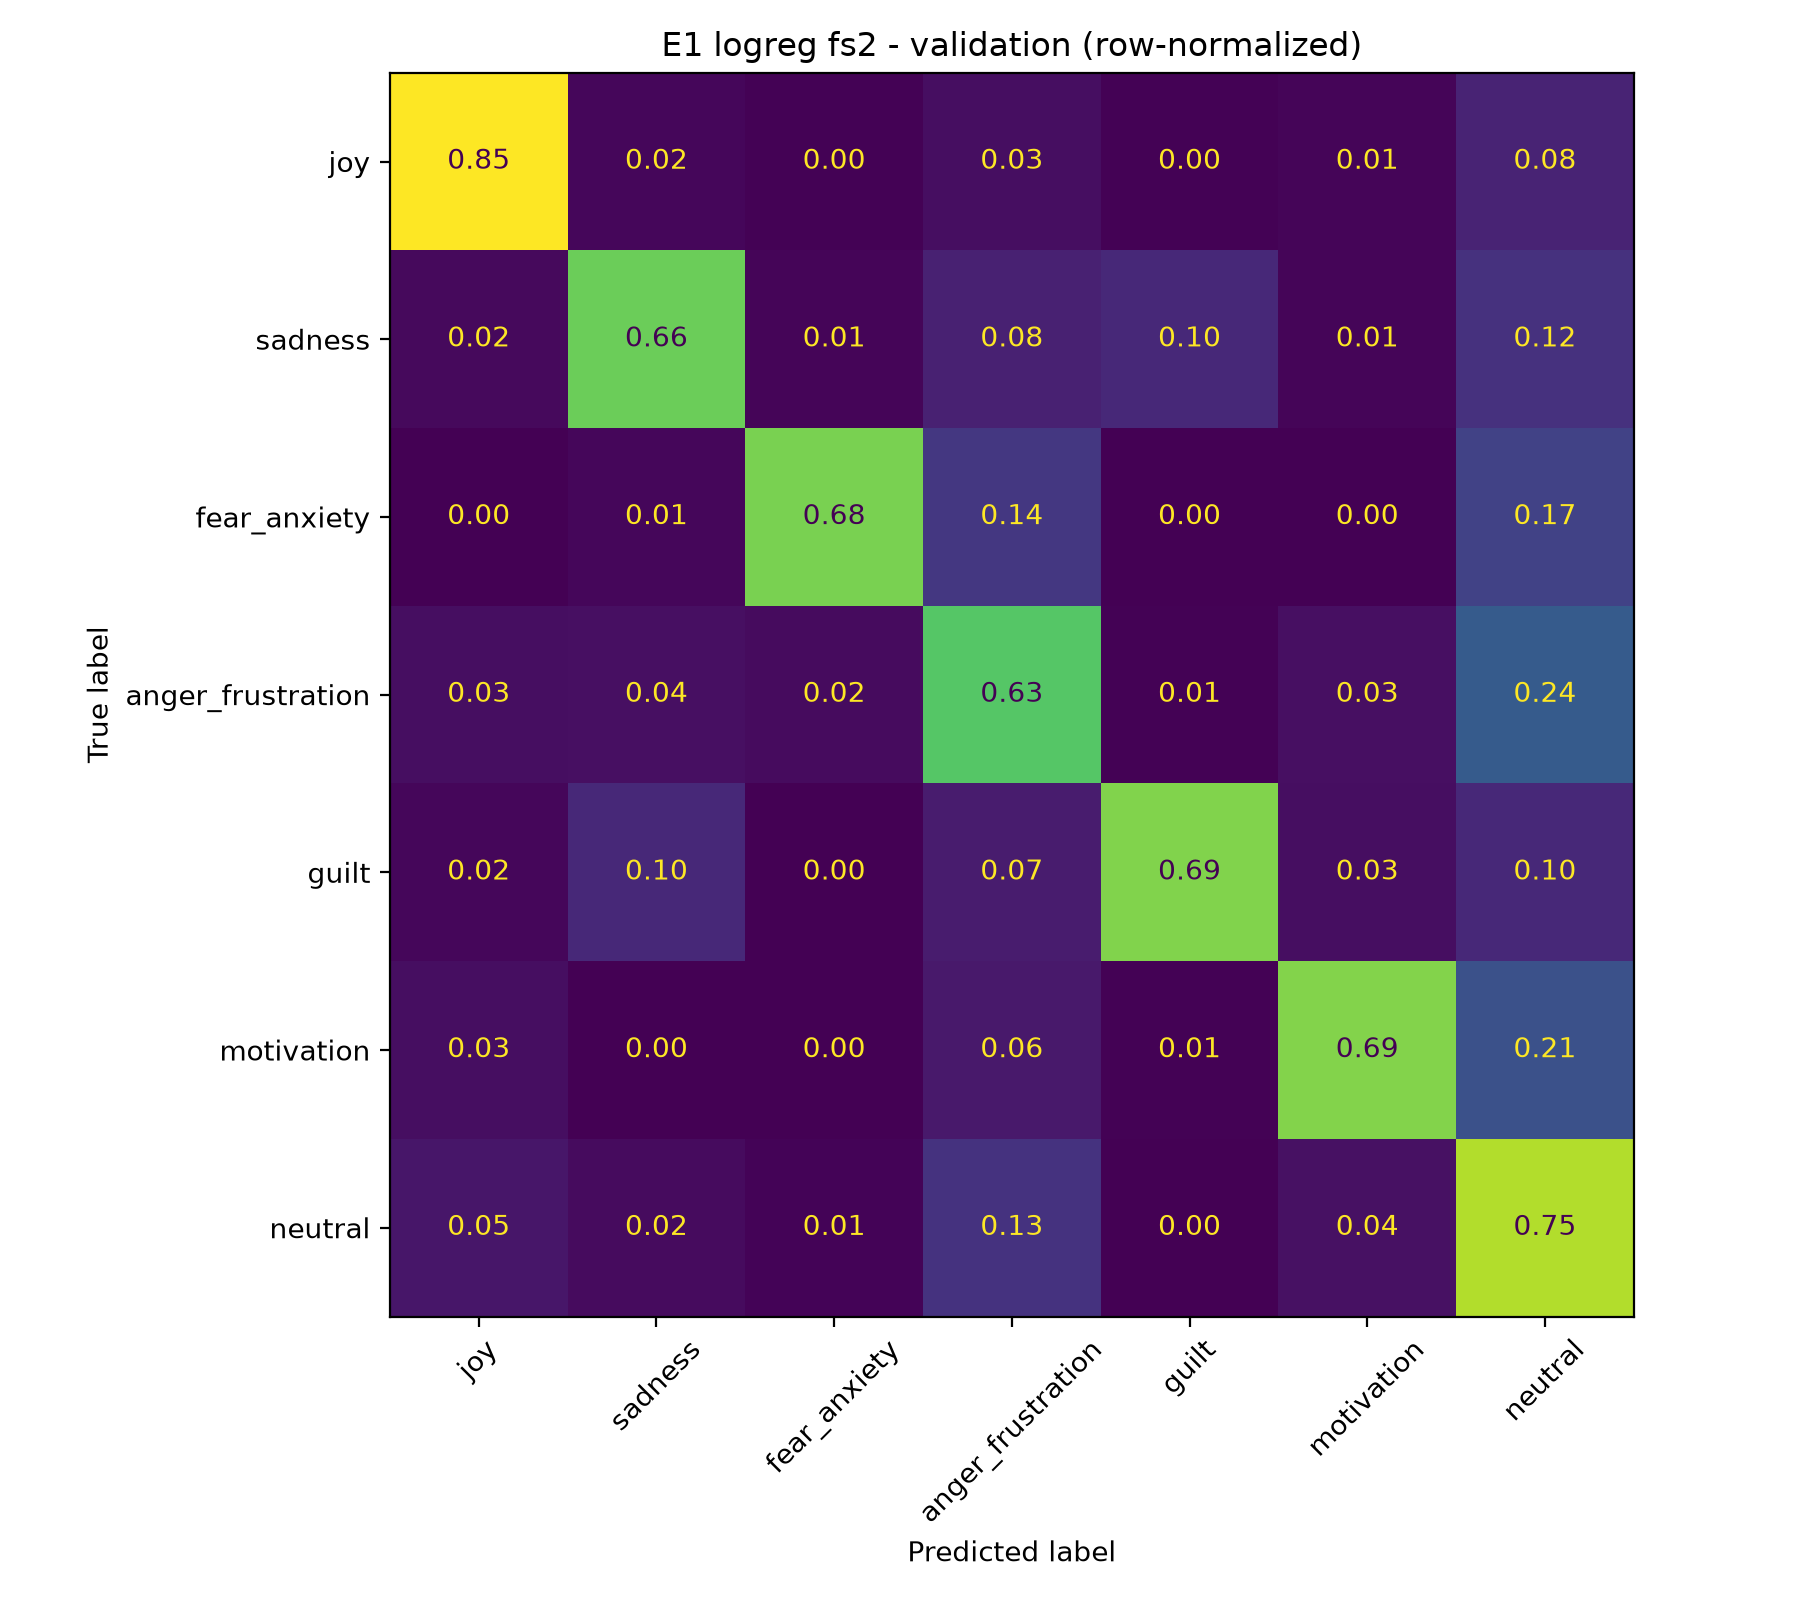

confusion_matrix_E1_validation_normalized.png


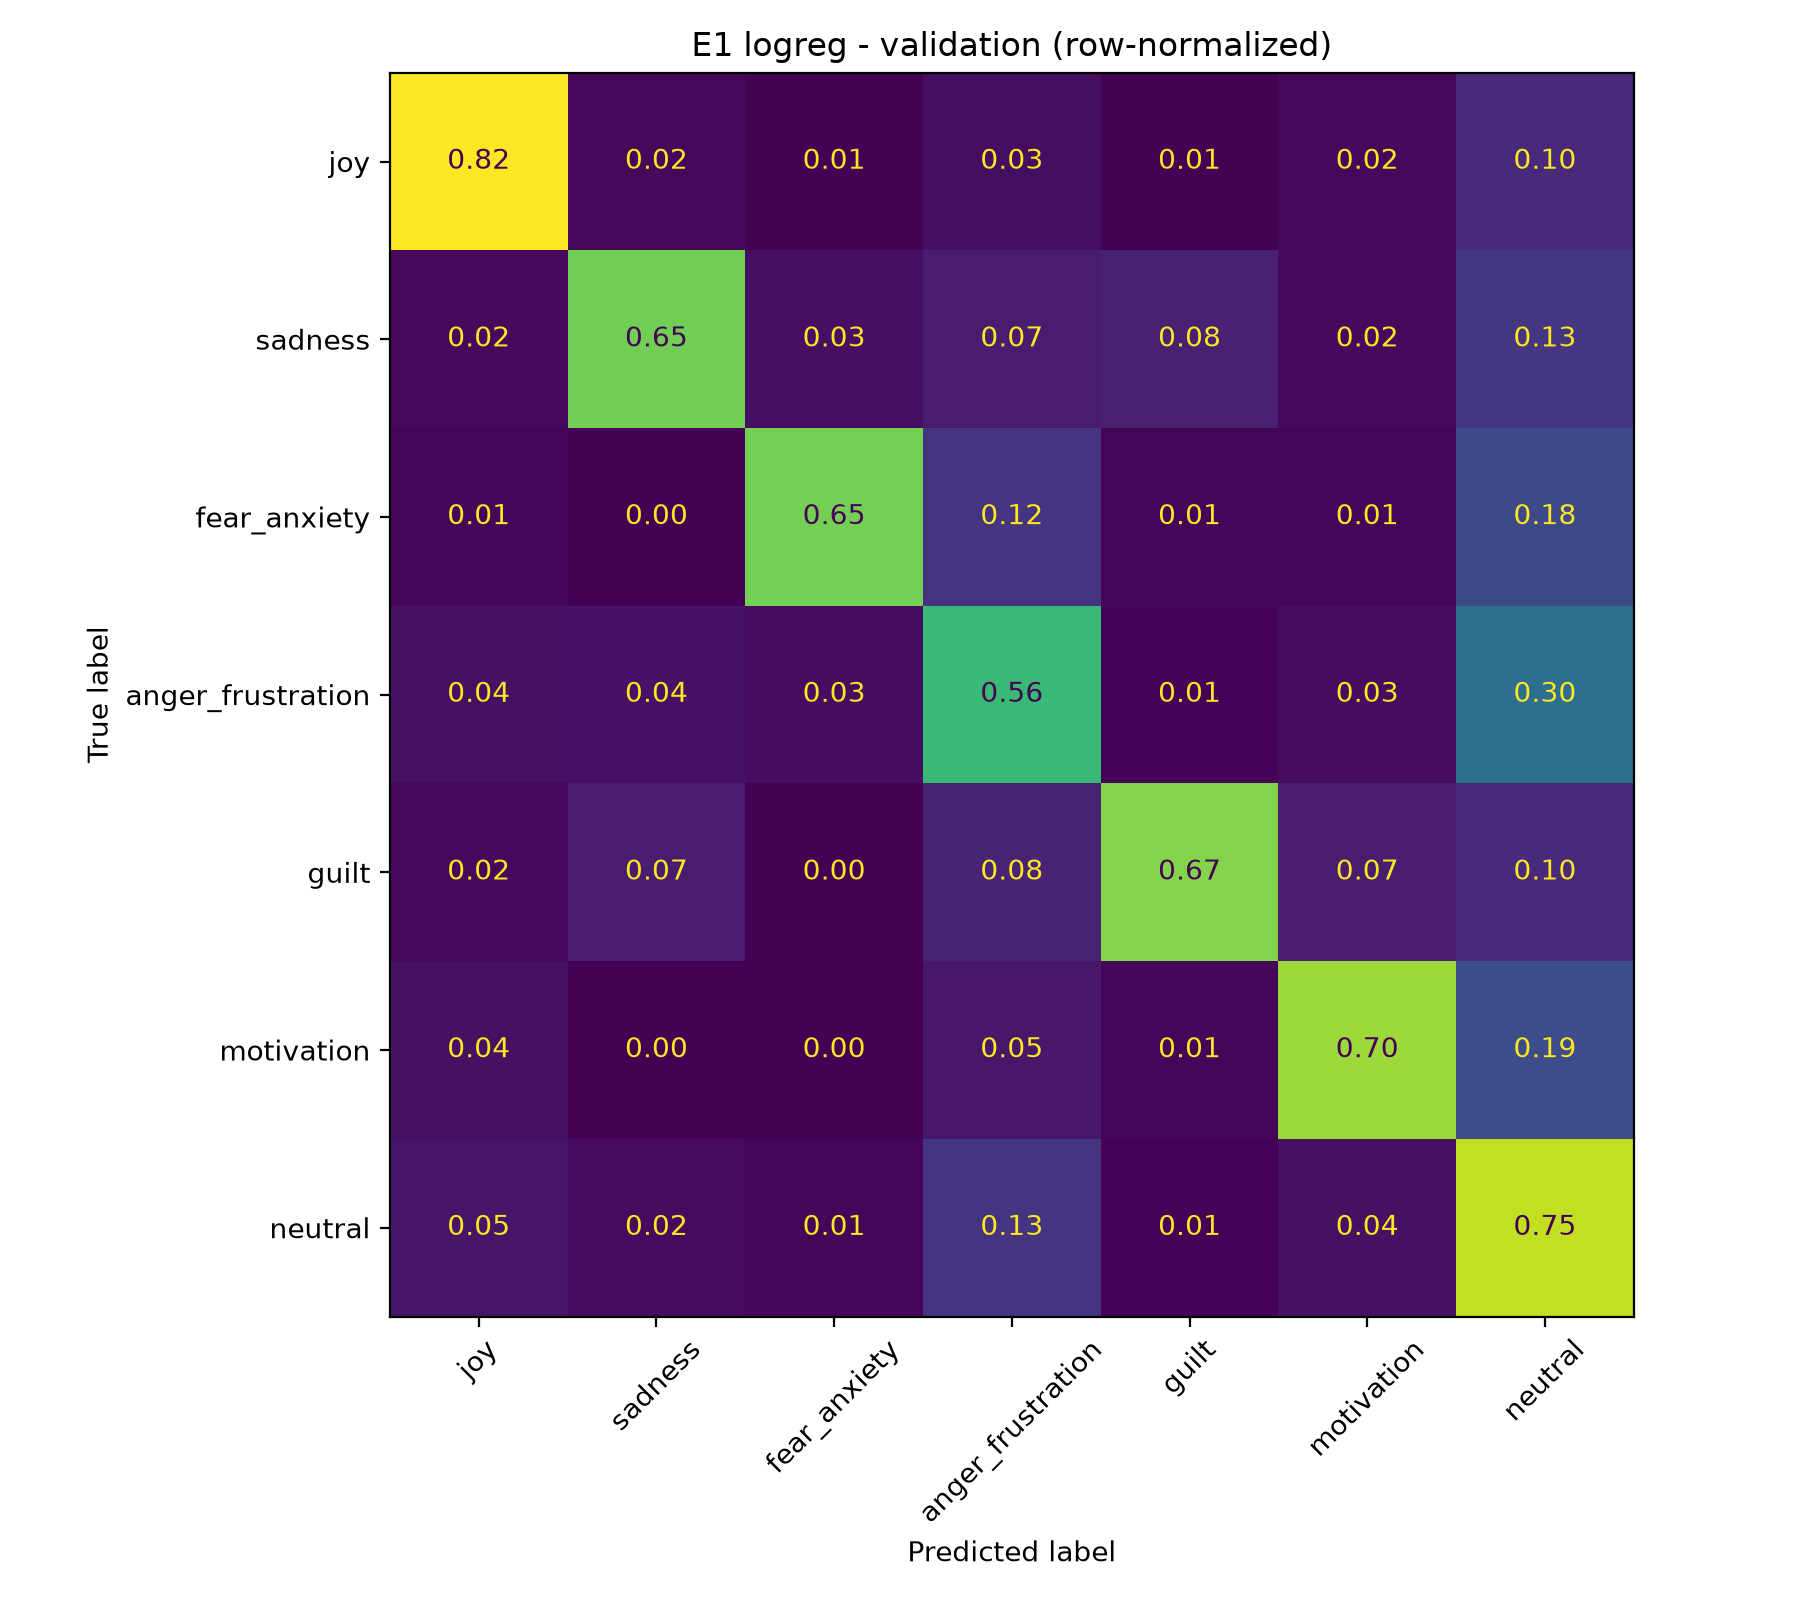

confusion_matrix_E2_fs2_validation_normalized.png


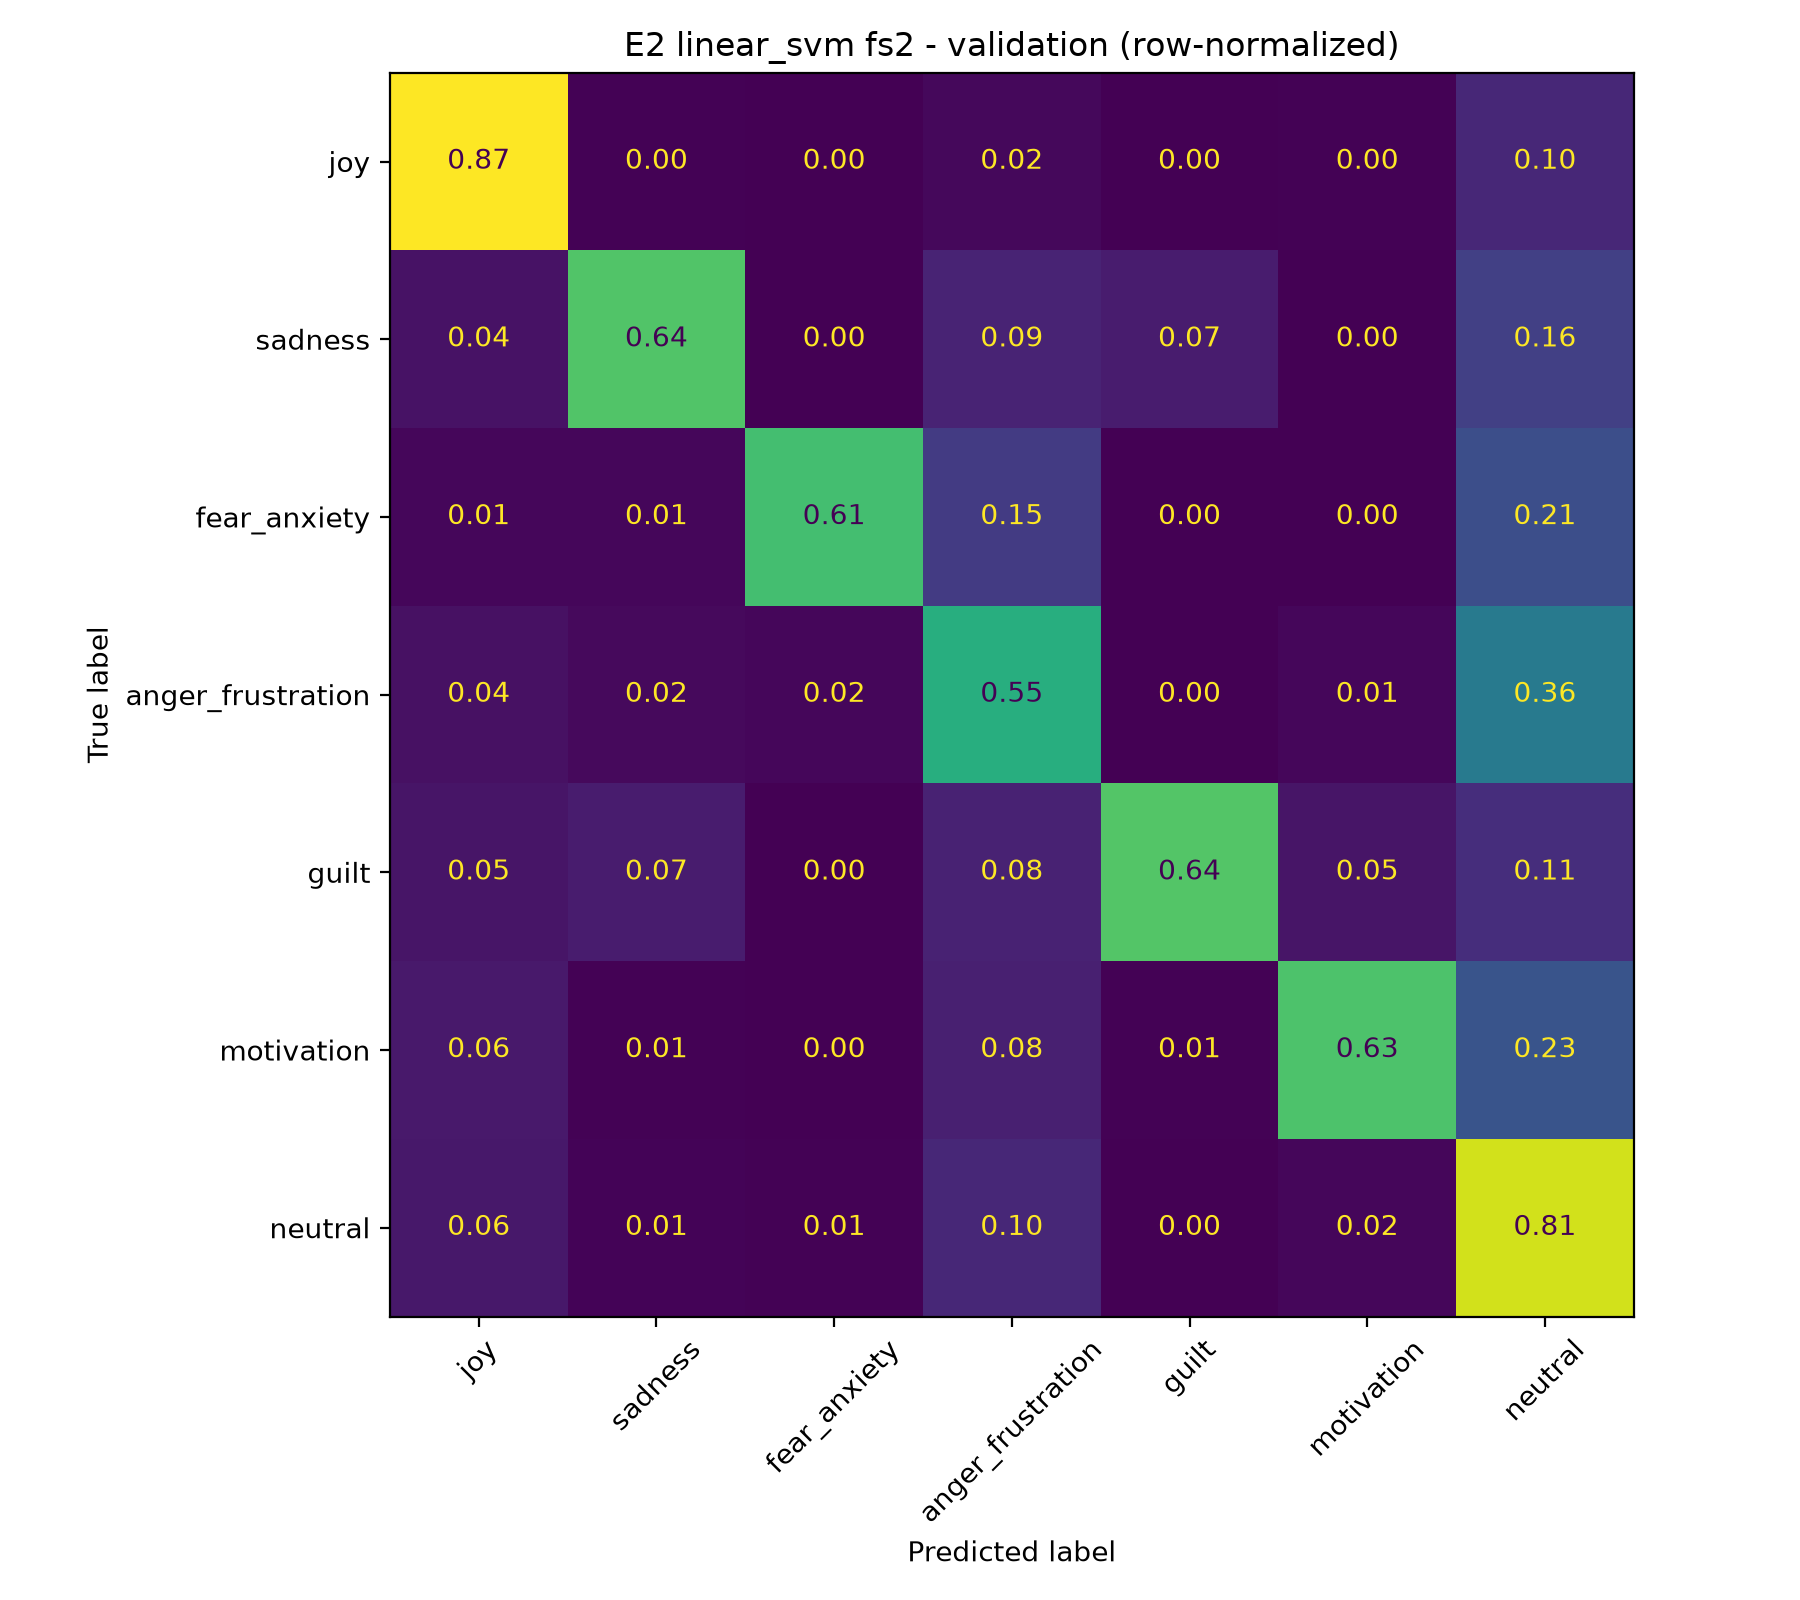

confusion_matrix_E2_validation_normalized.png


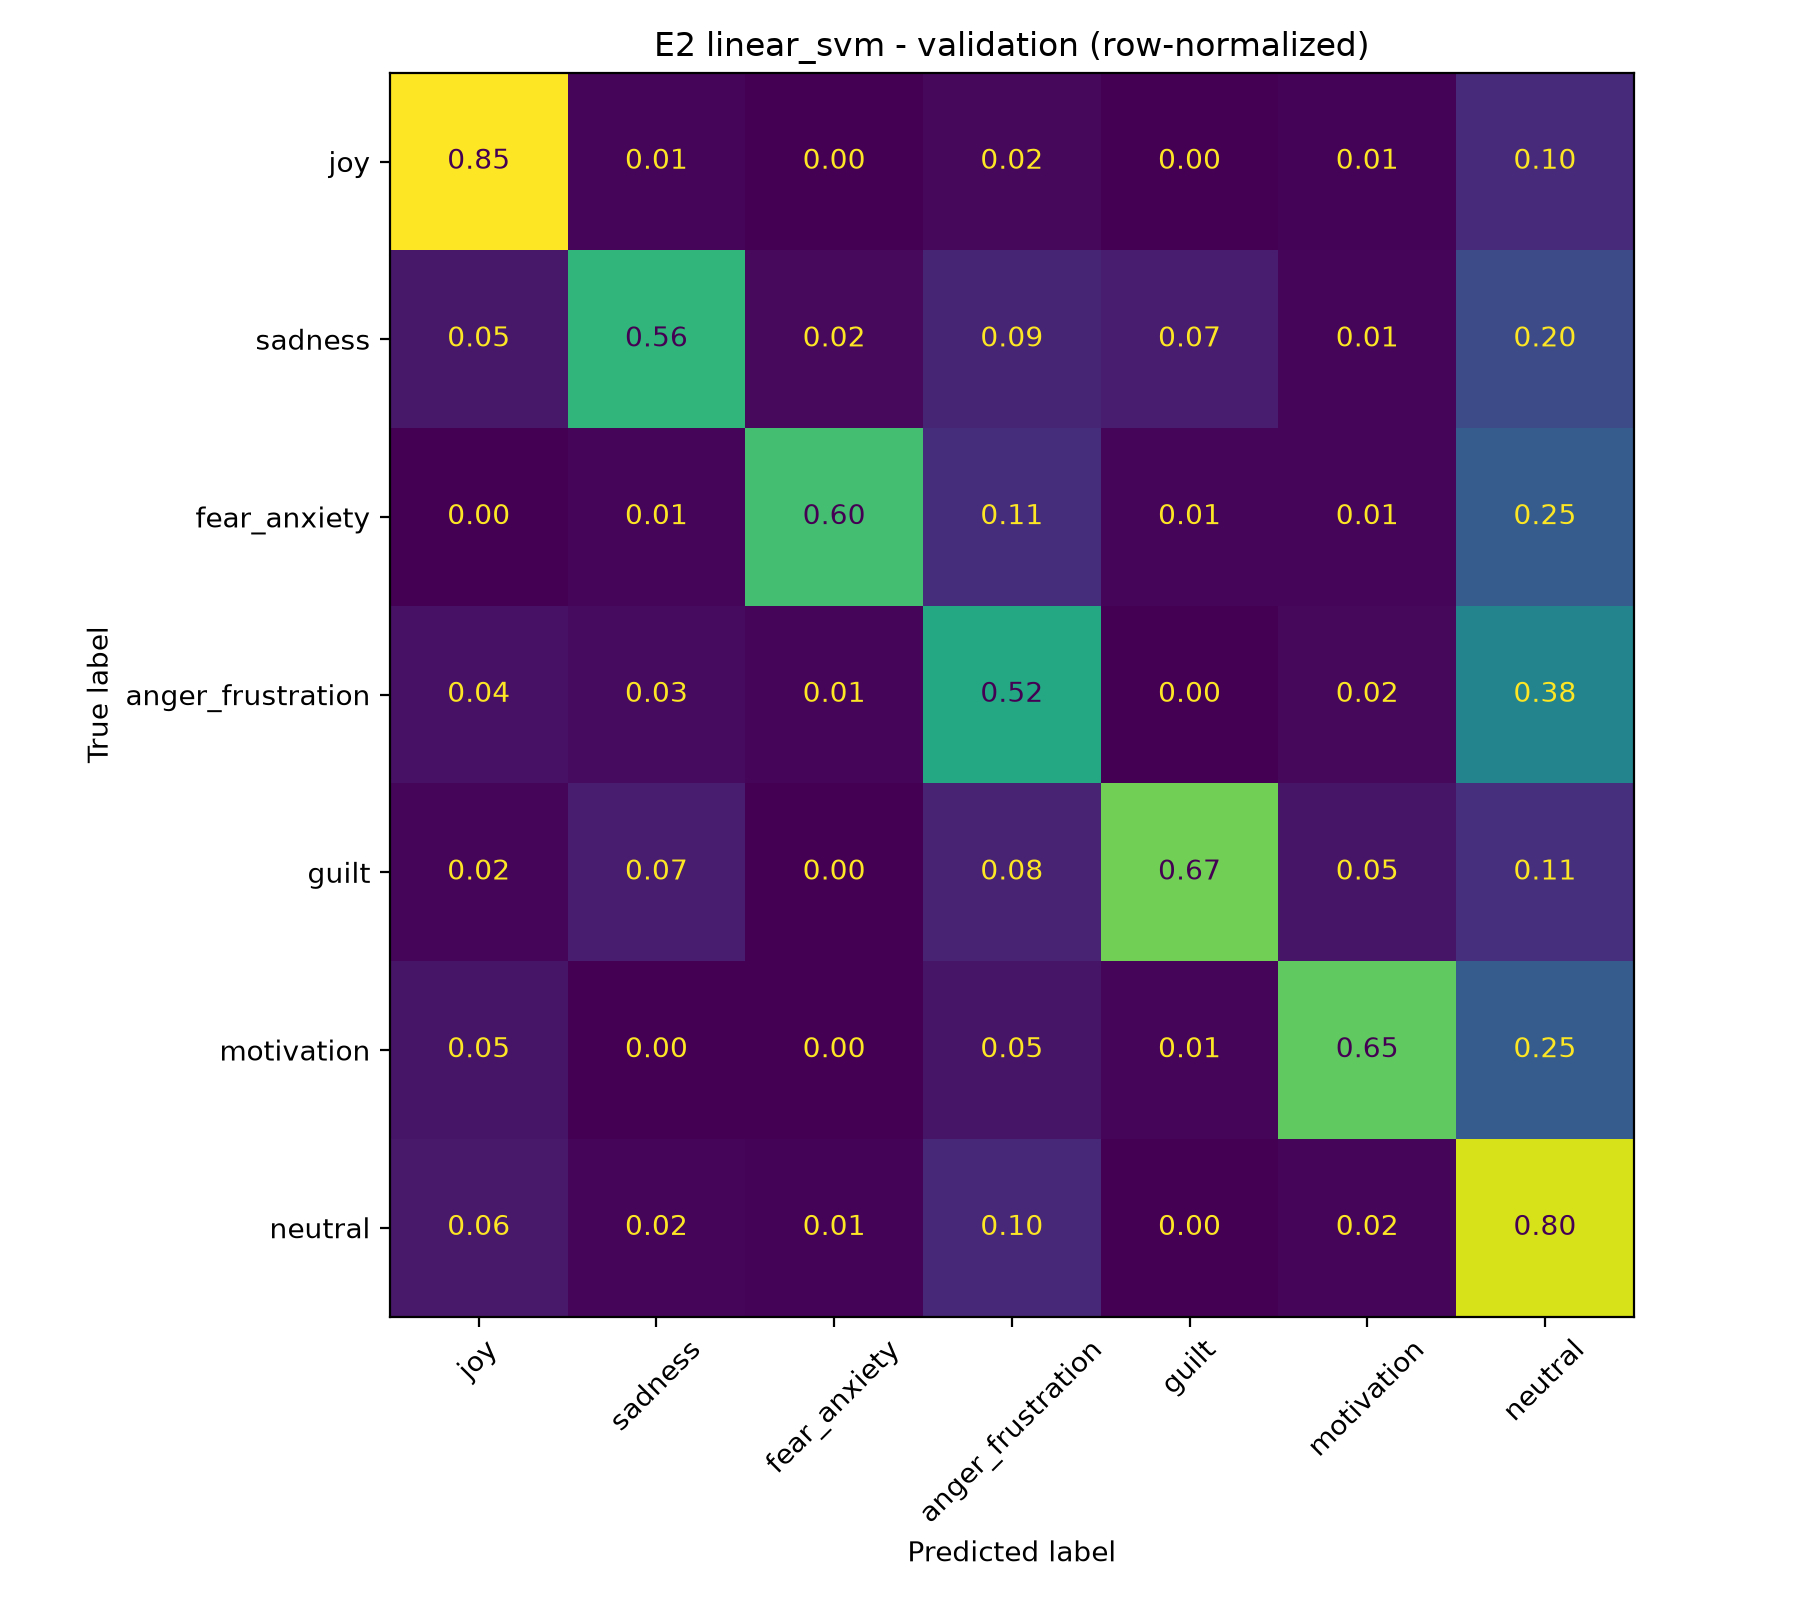

confusion_matrix_E3-cal_fs2_validation_normalized.png


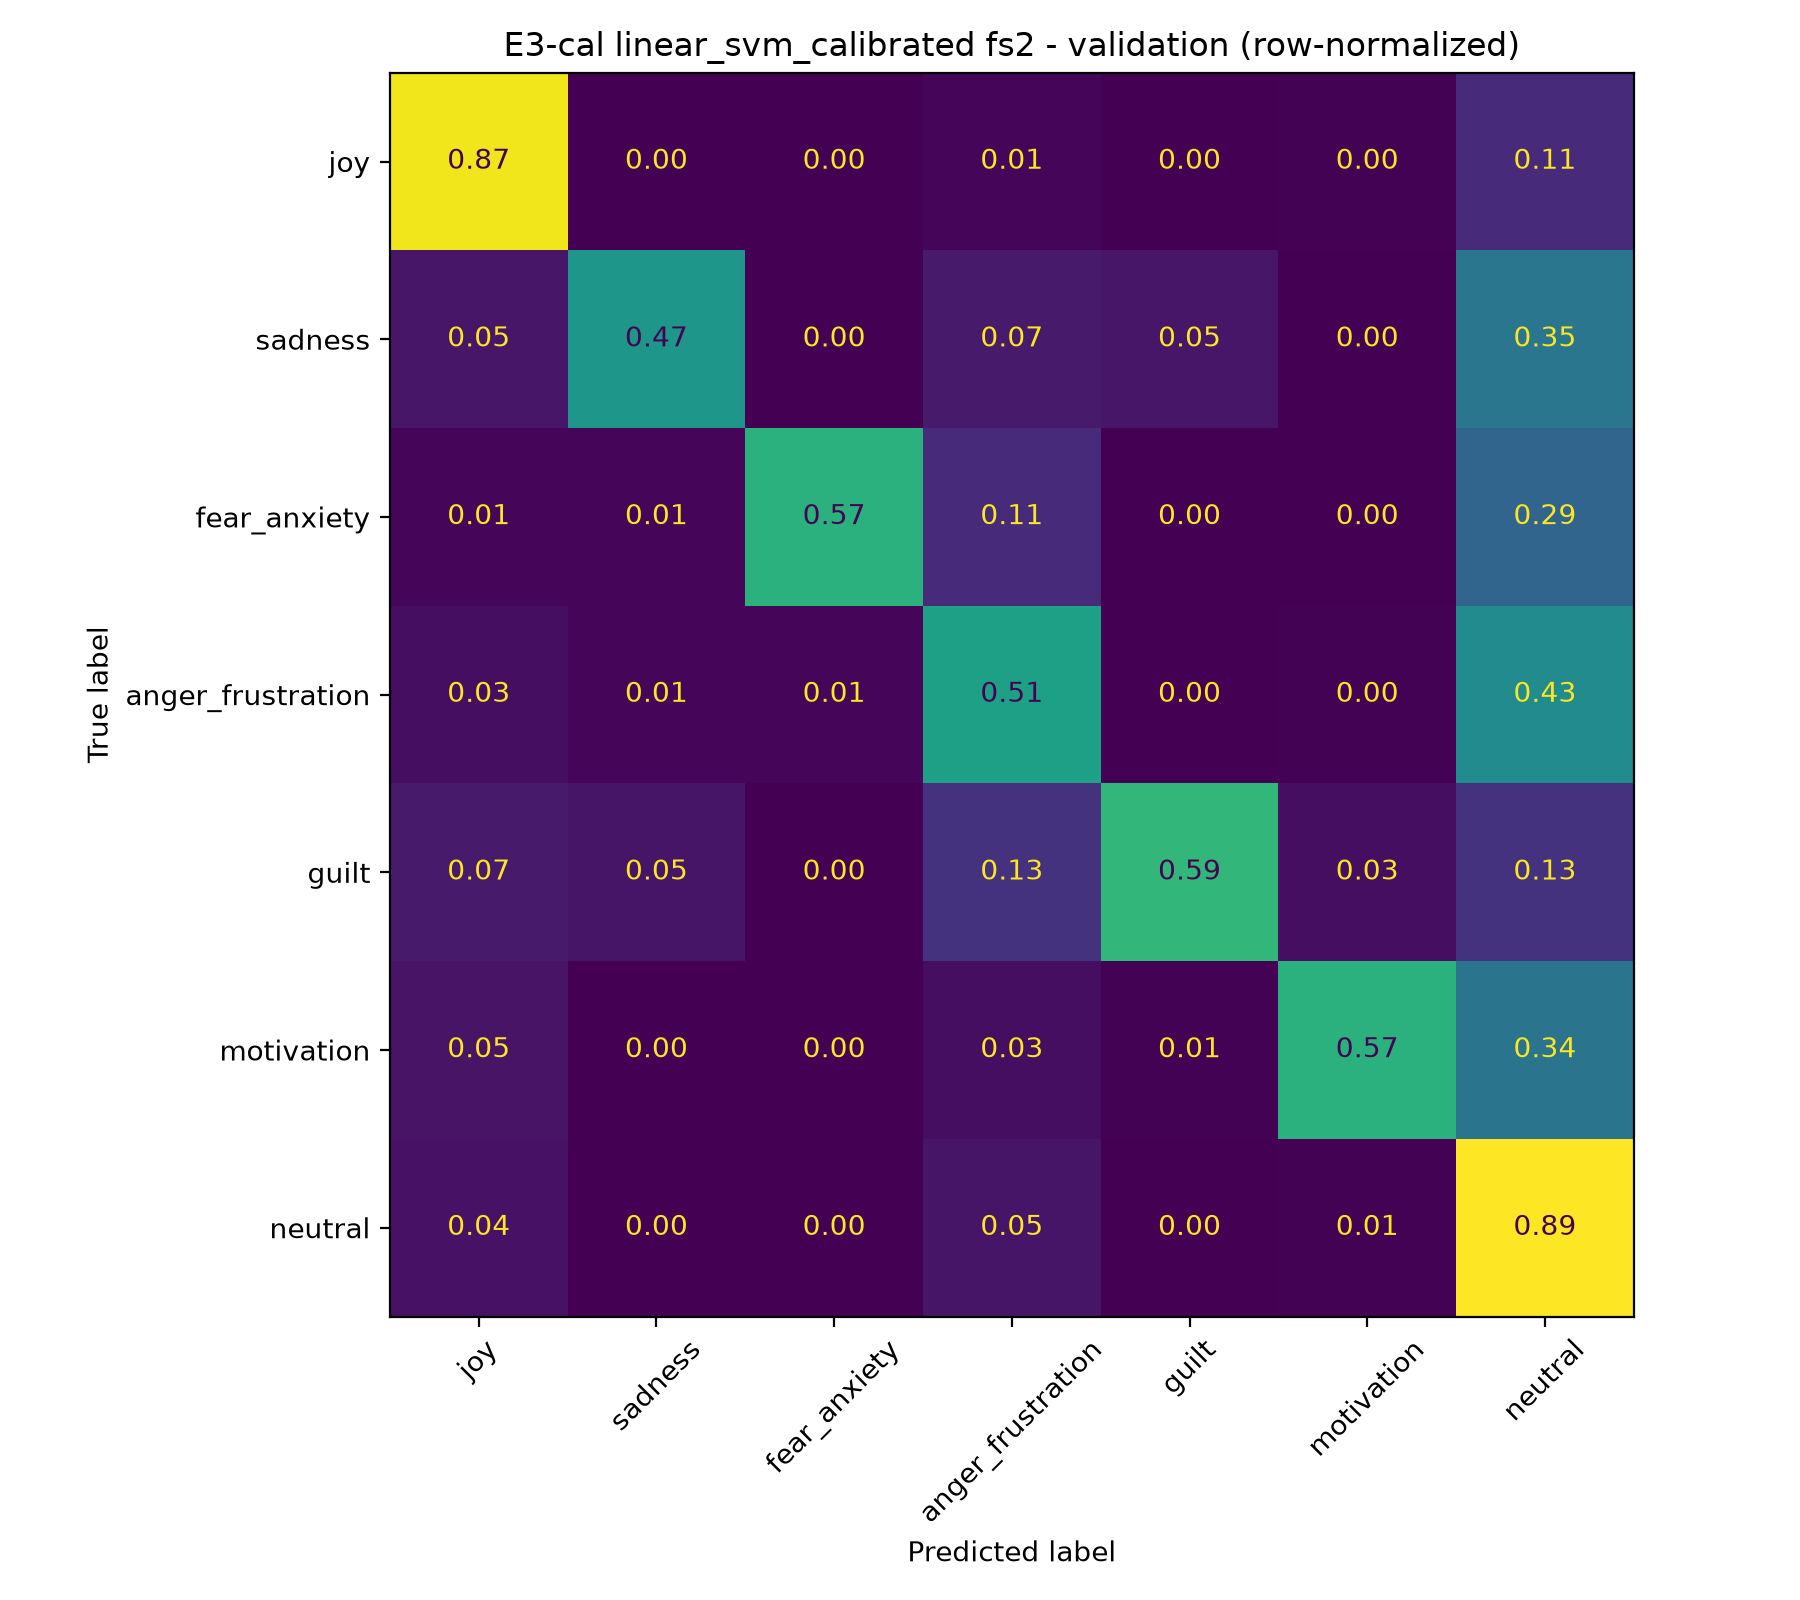

confusion_matrix_E3-cal_validation_normalized.png


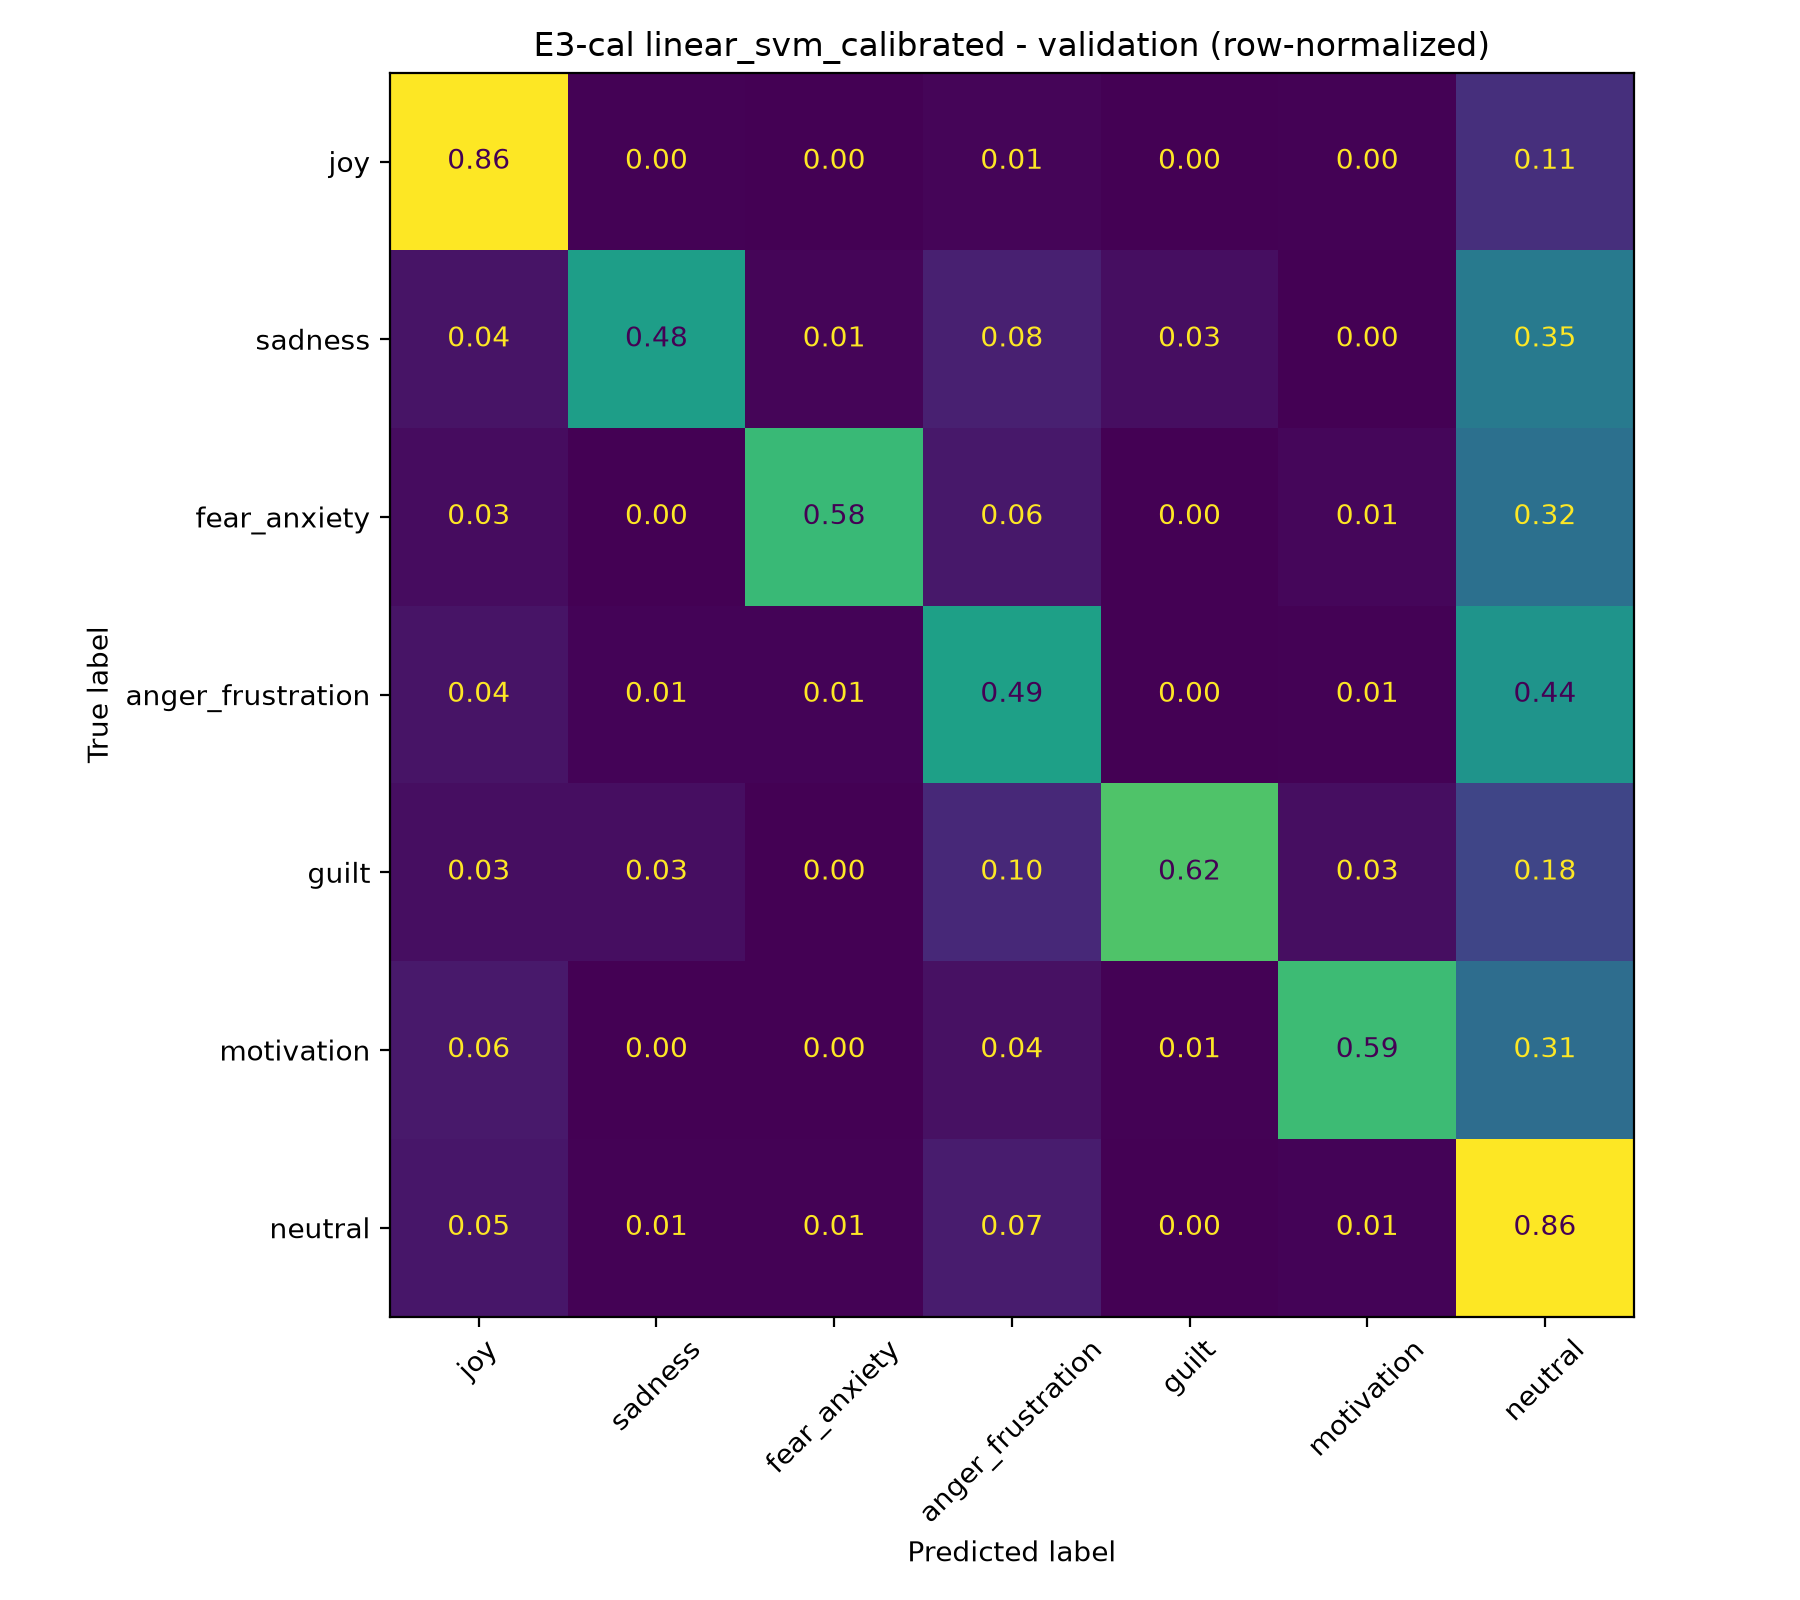

confusion_matrix_E3-iso_fs2_validation_normalized.png


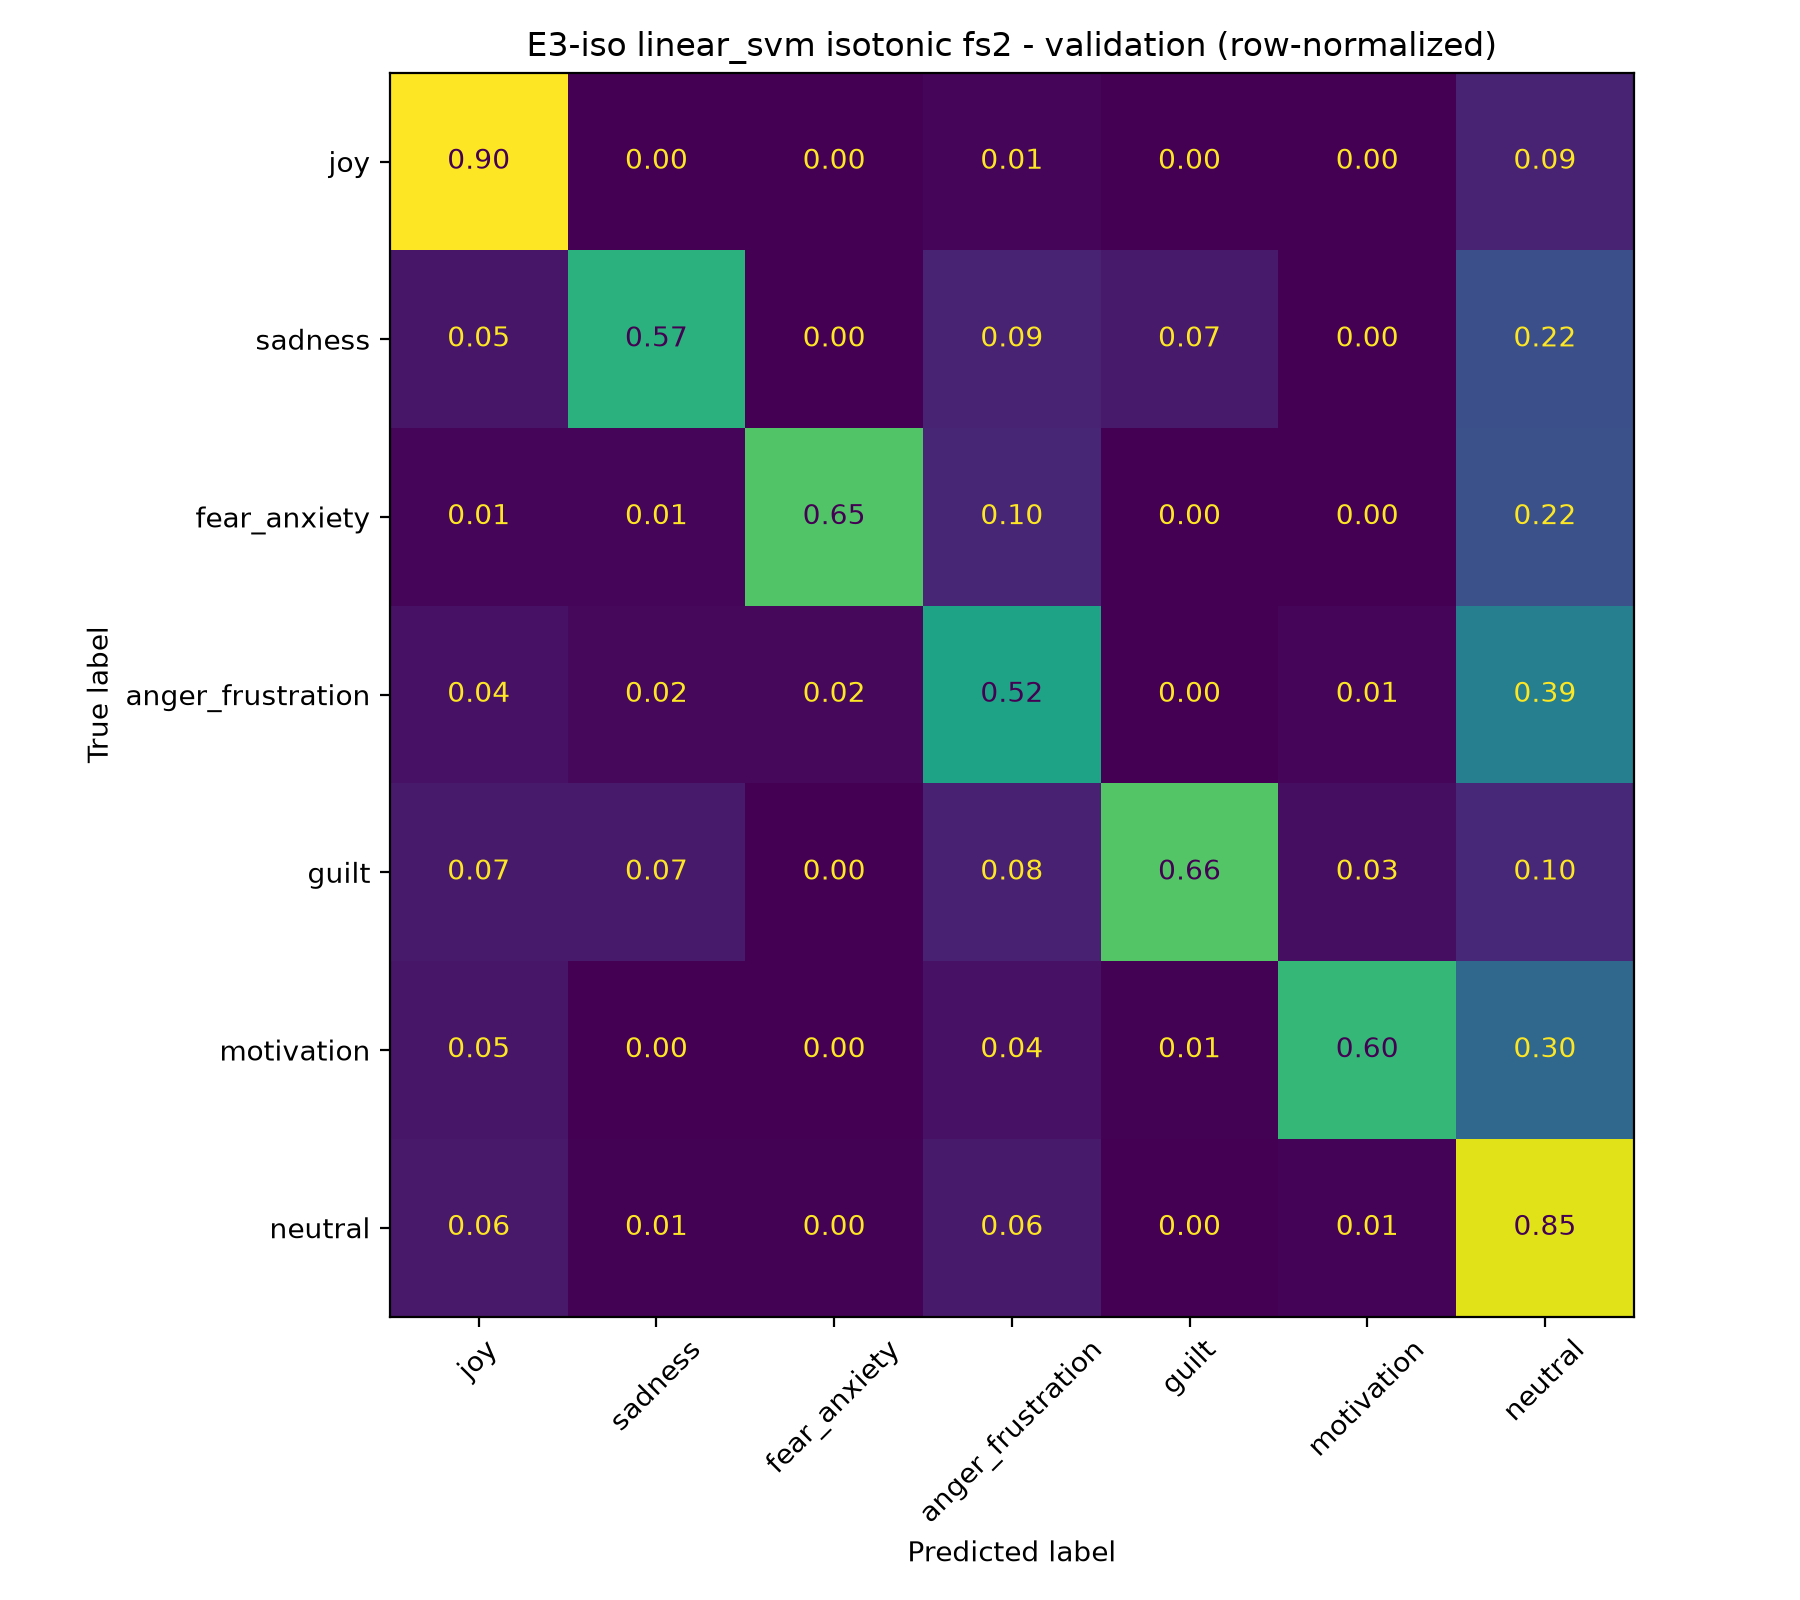

confusion_matrix_E3_fs2_validation_normalized.png


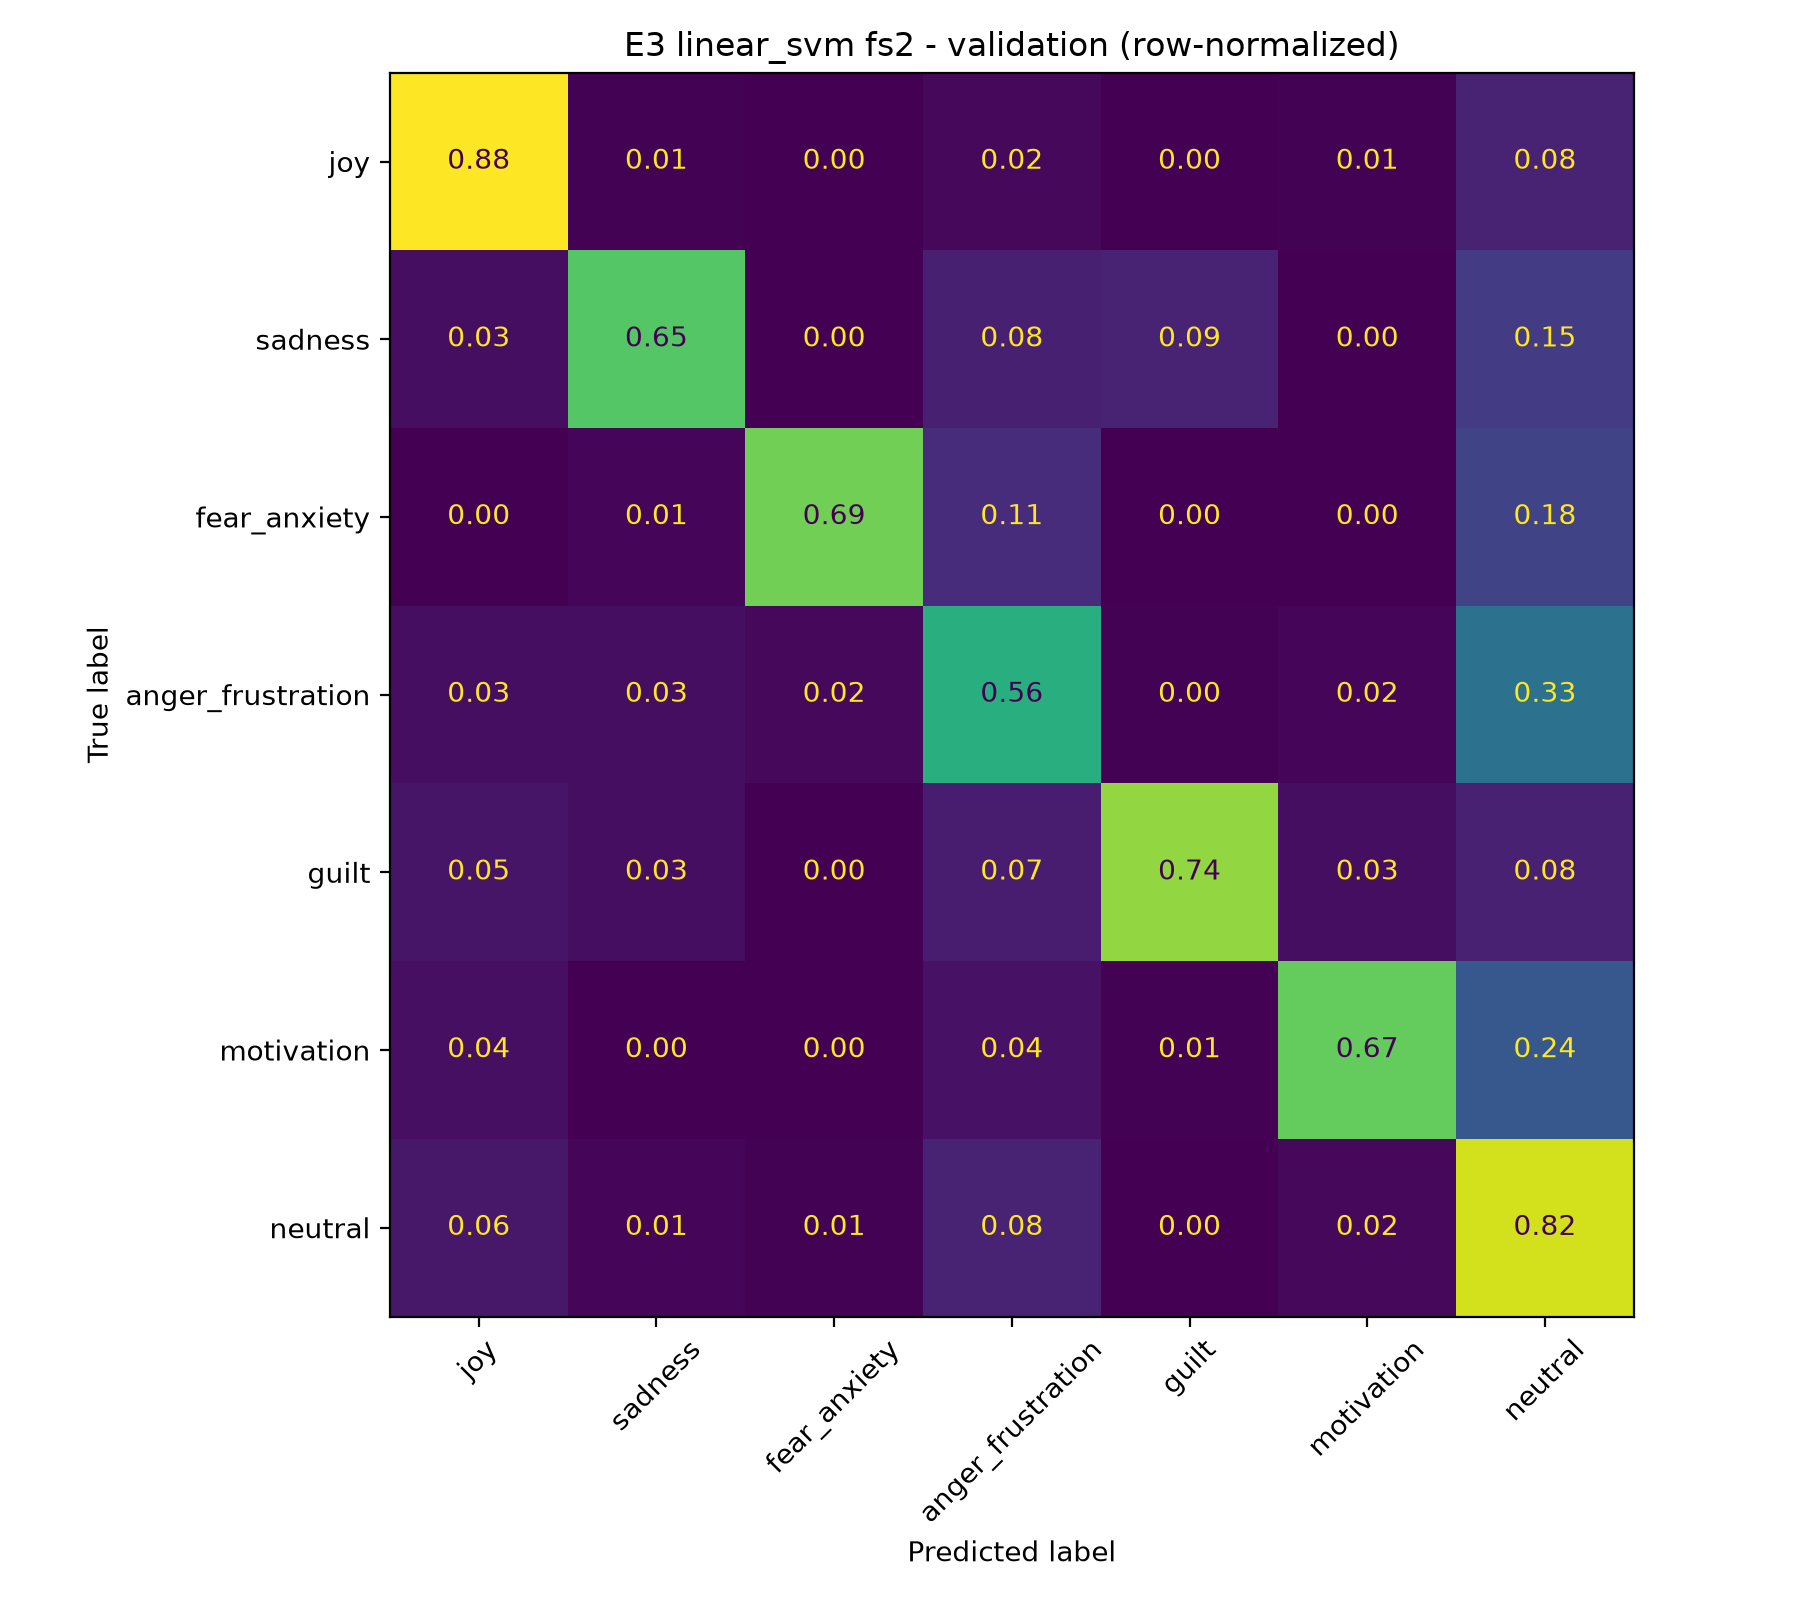

confusion_matrix_E3_validation_normalized.png


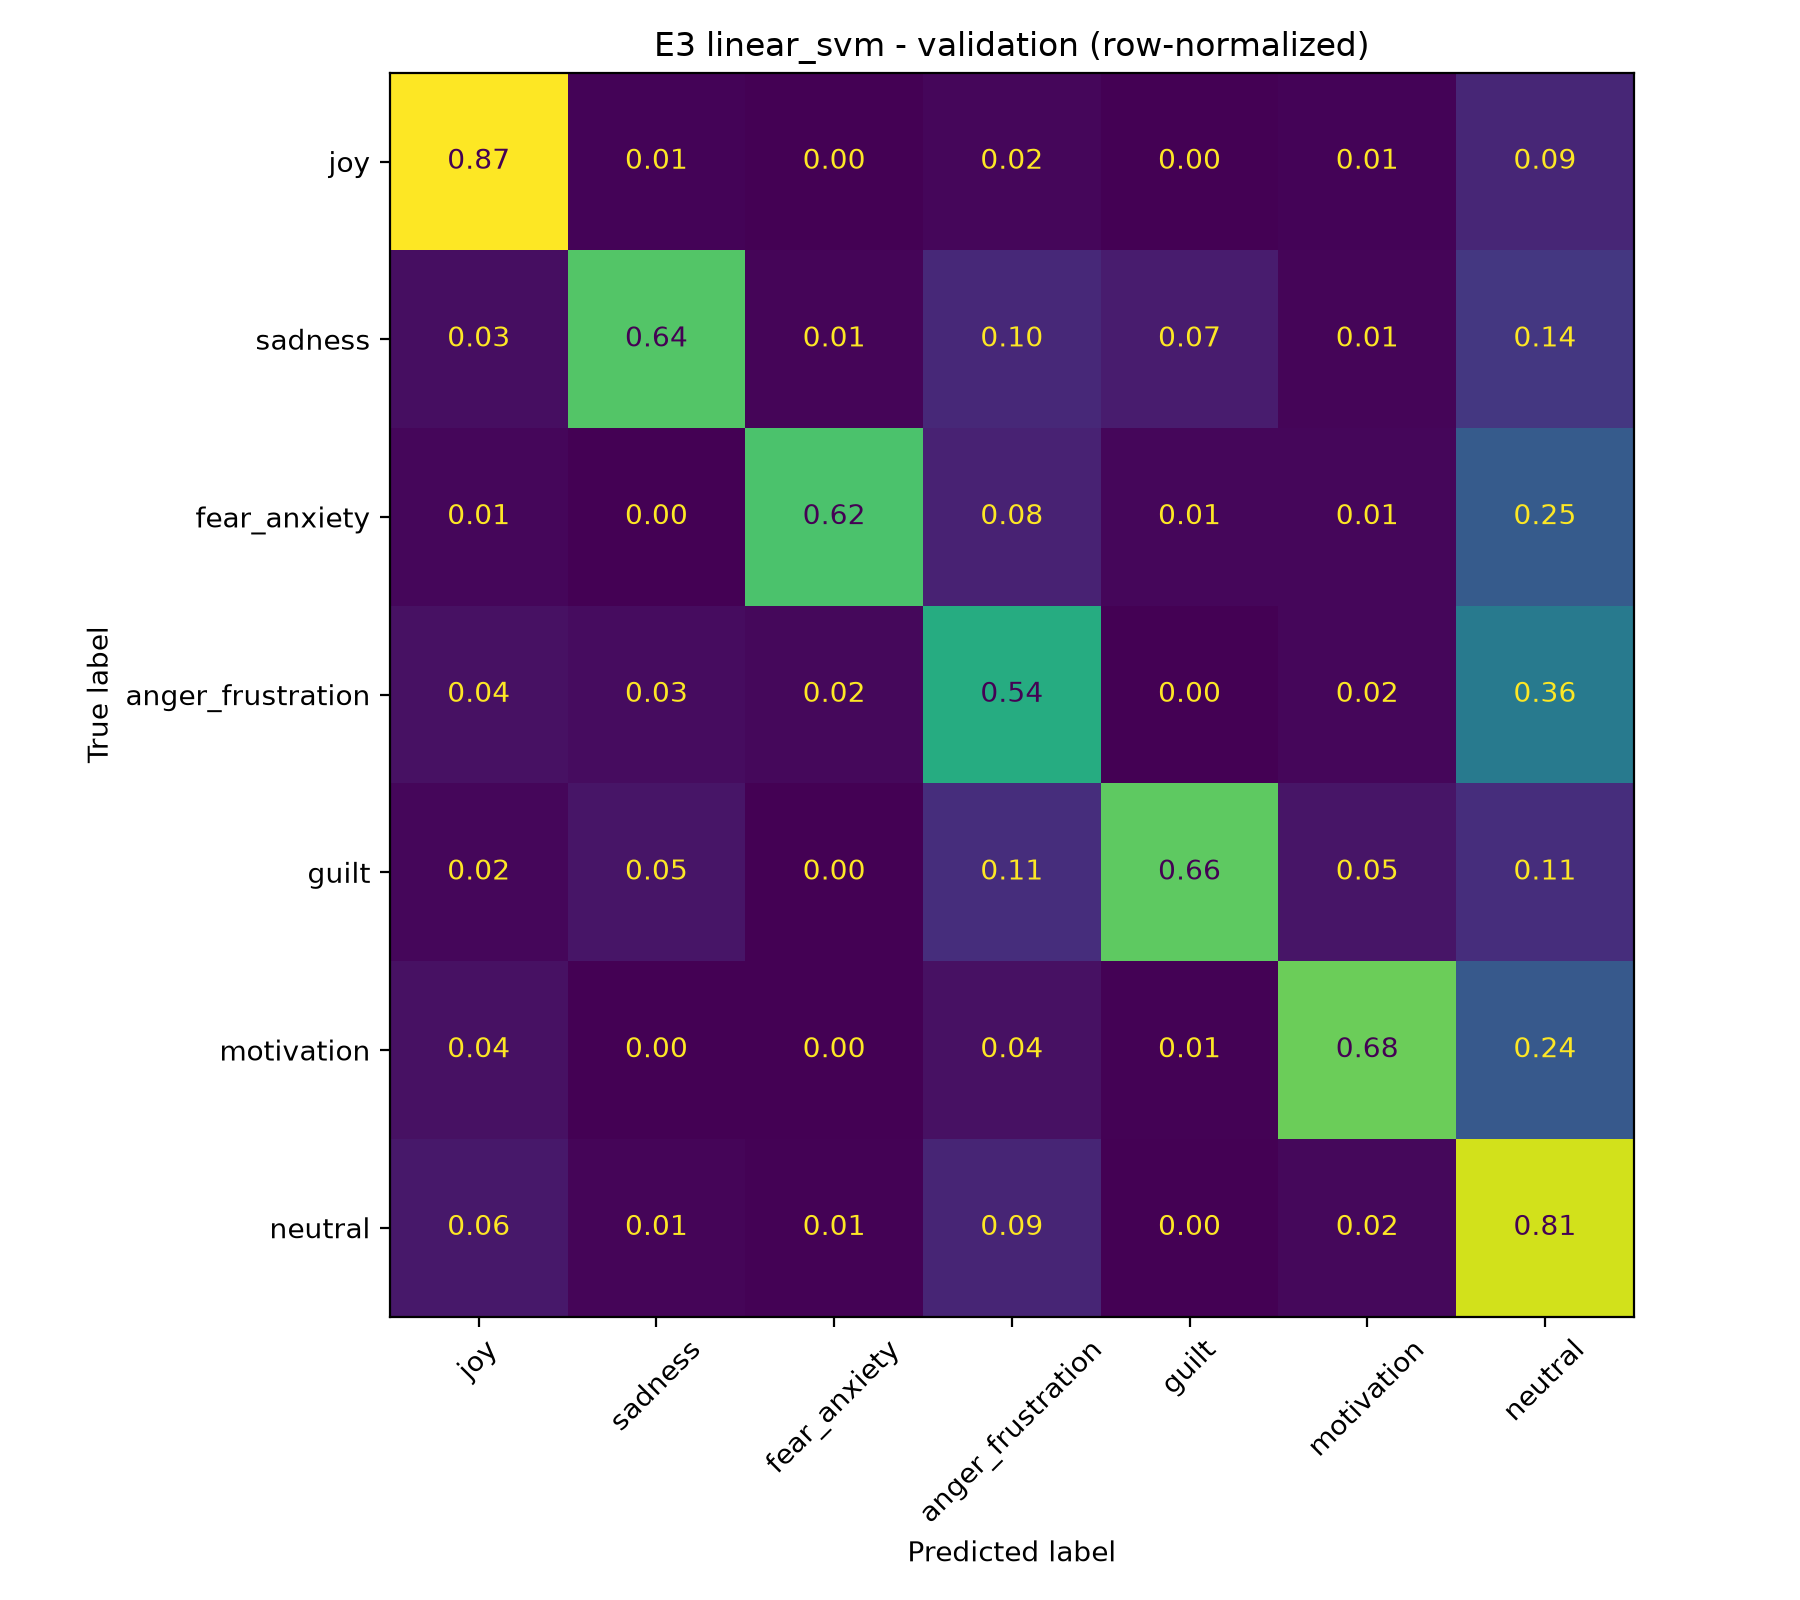

confusion_matrix_E4_validation_normalized.png


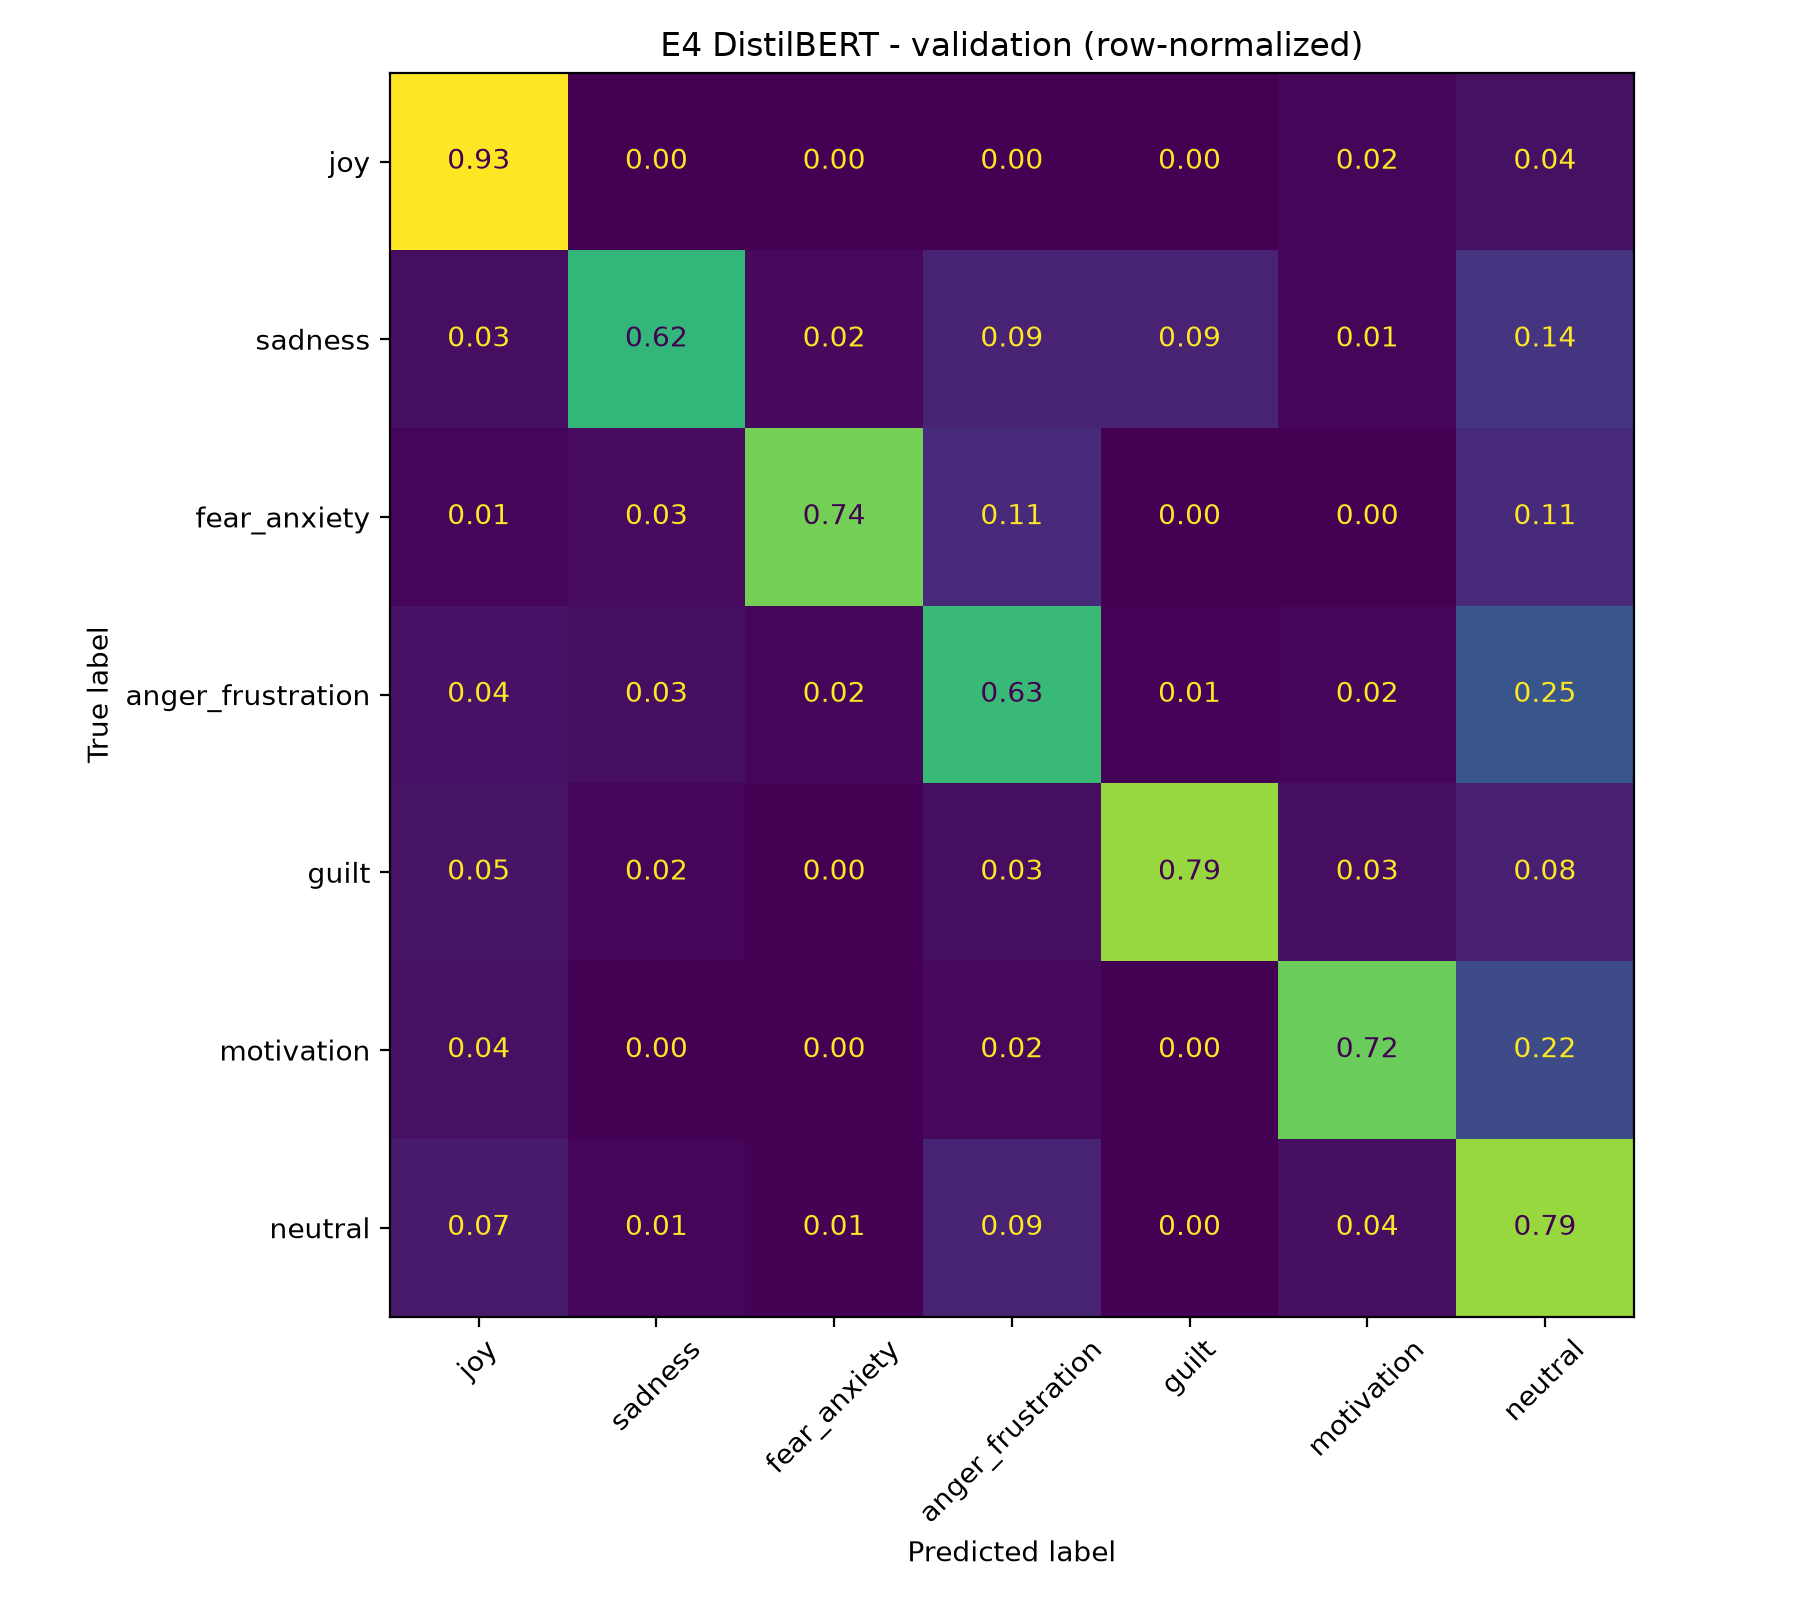

confusion_matrix_final_test_normalized.png


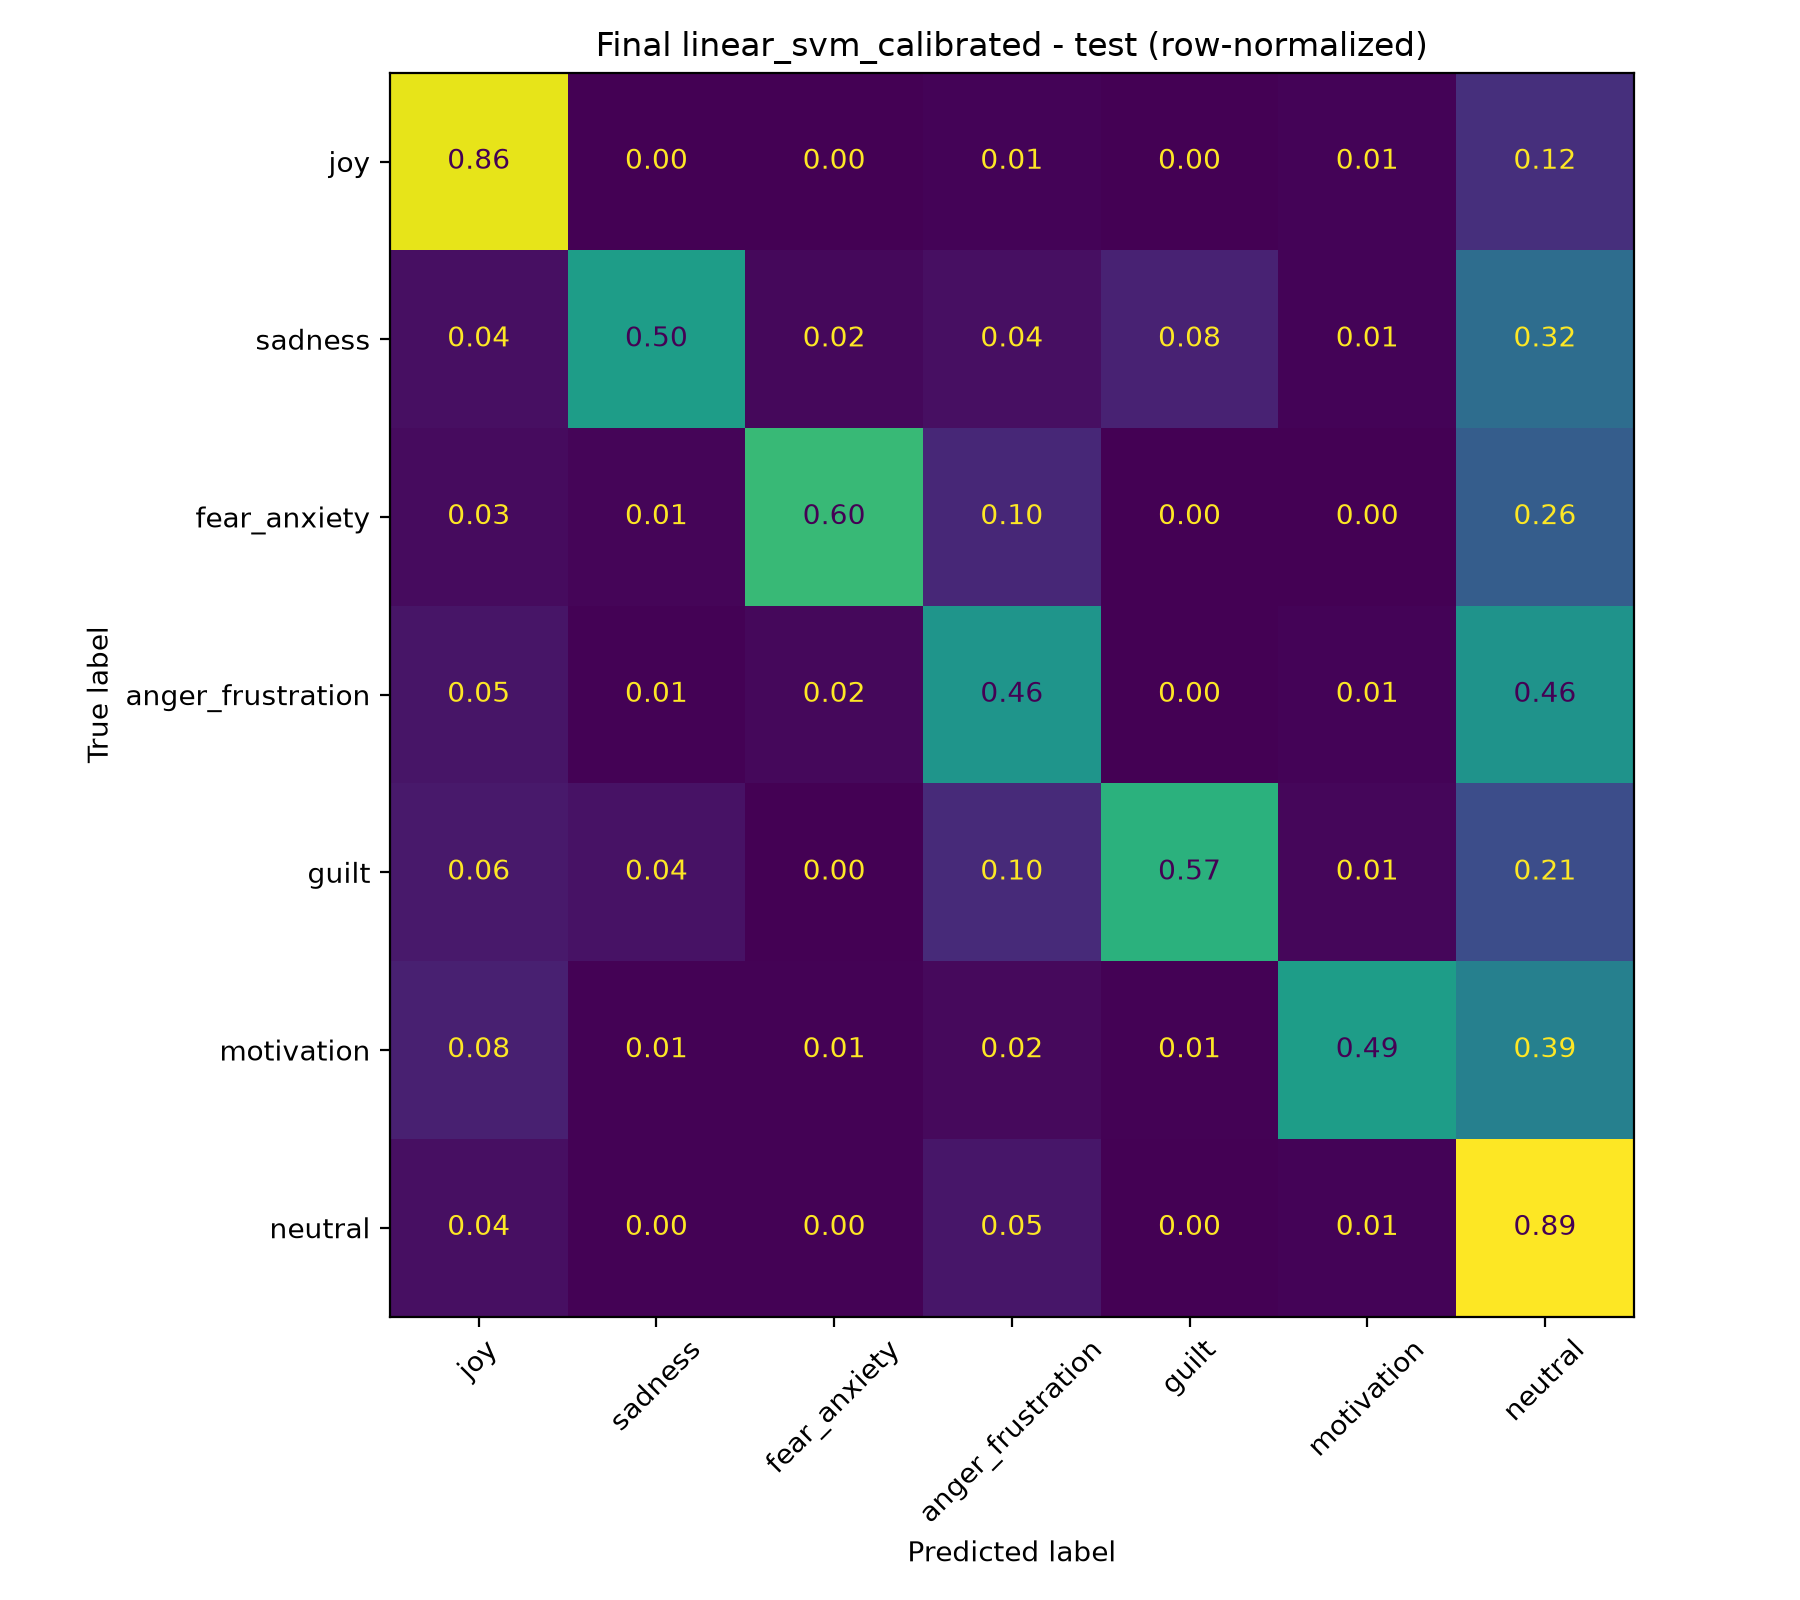

confusion_matrix_final_test_v2-distilbert-20260914_normalized.png


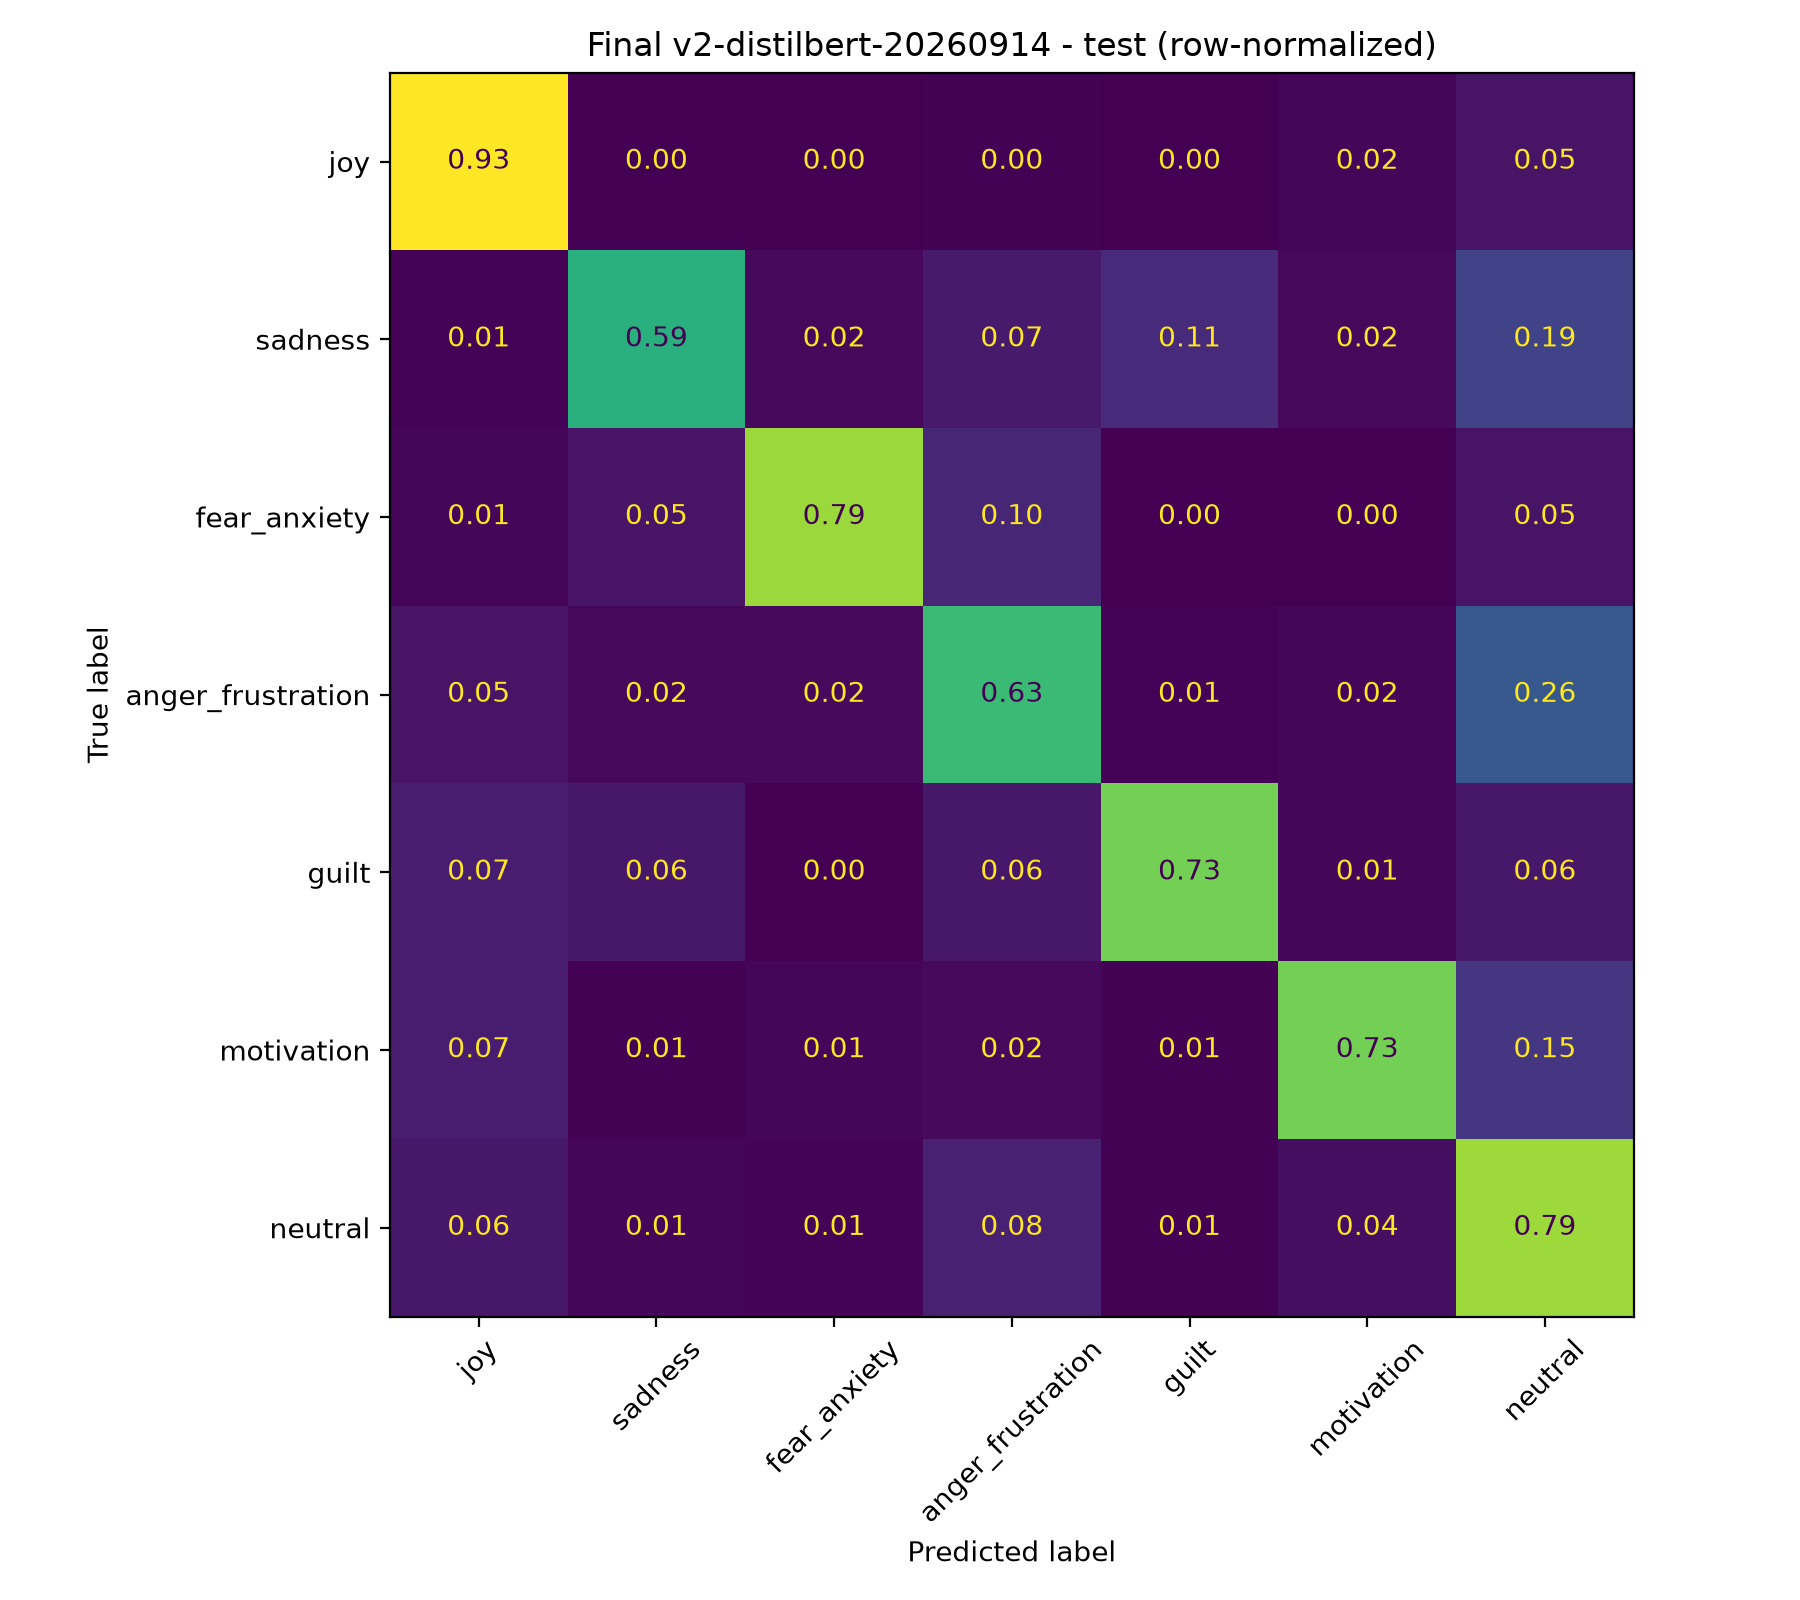

confusion_matrix_final_test_v2-fs2-linear_svm_calibrated-20260914_normalized.png


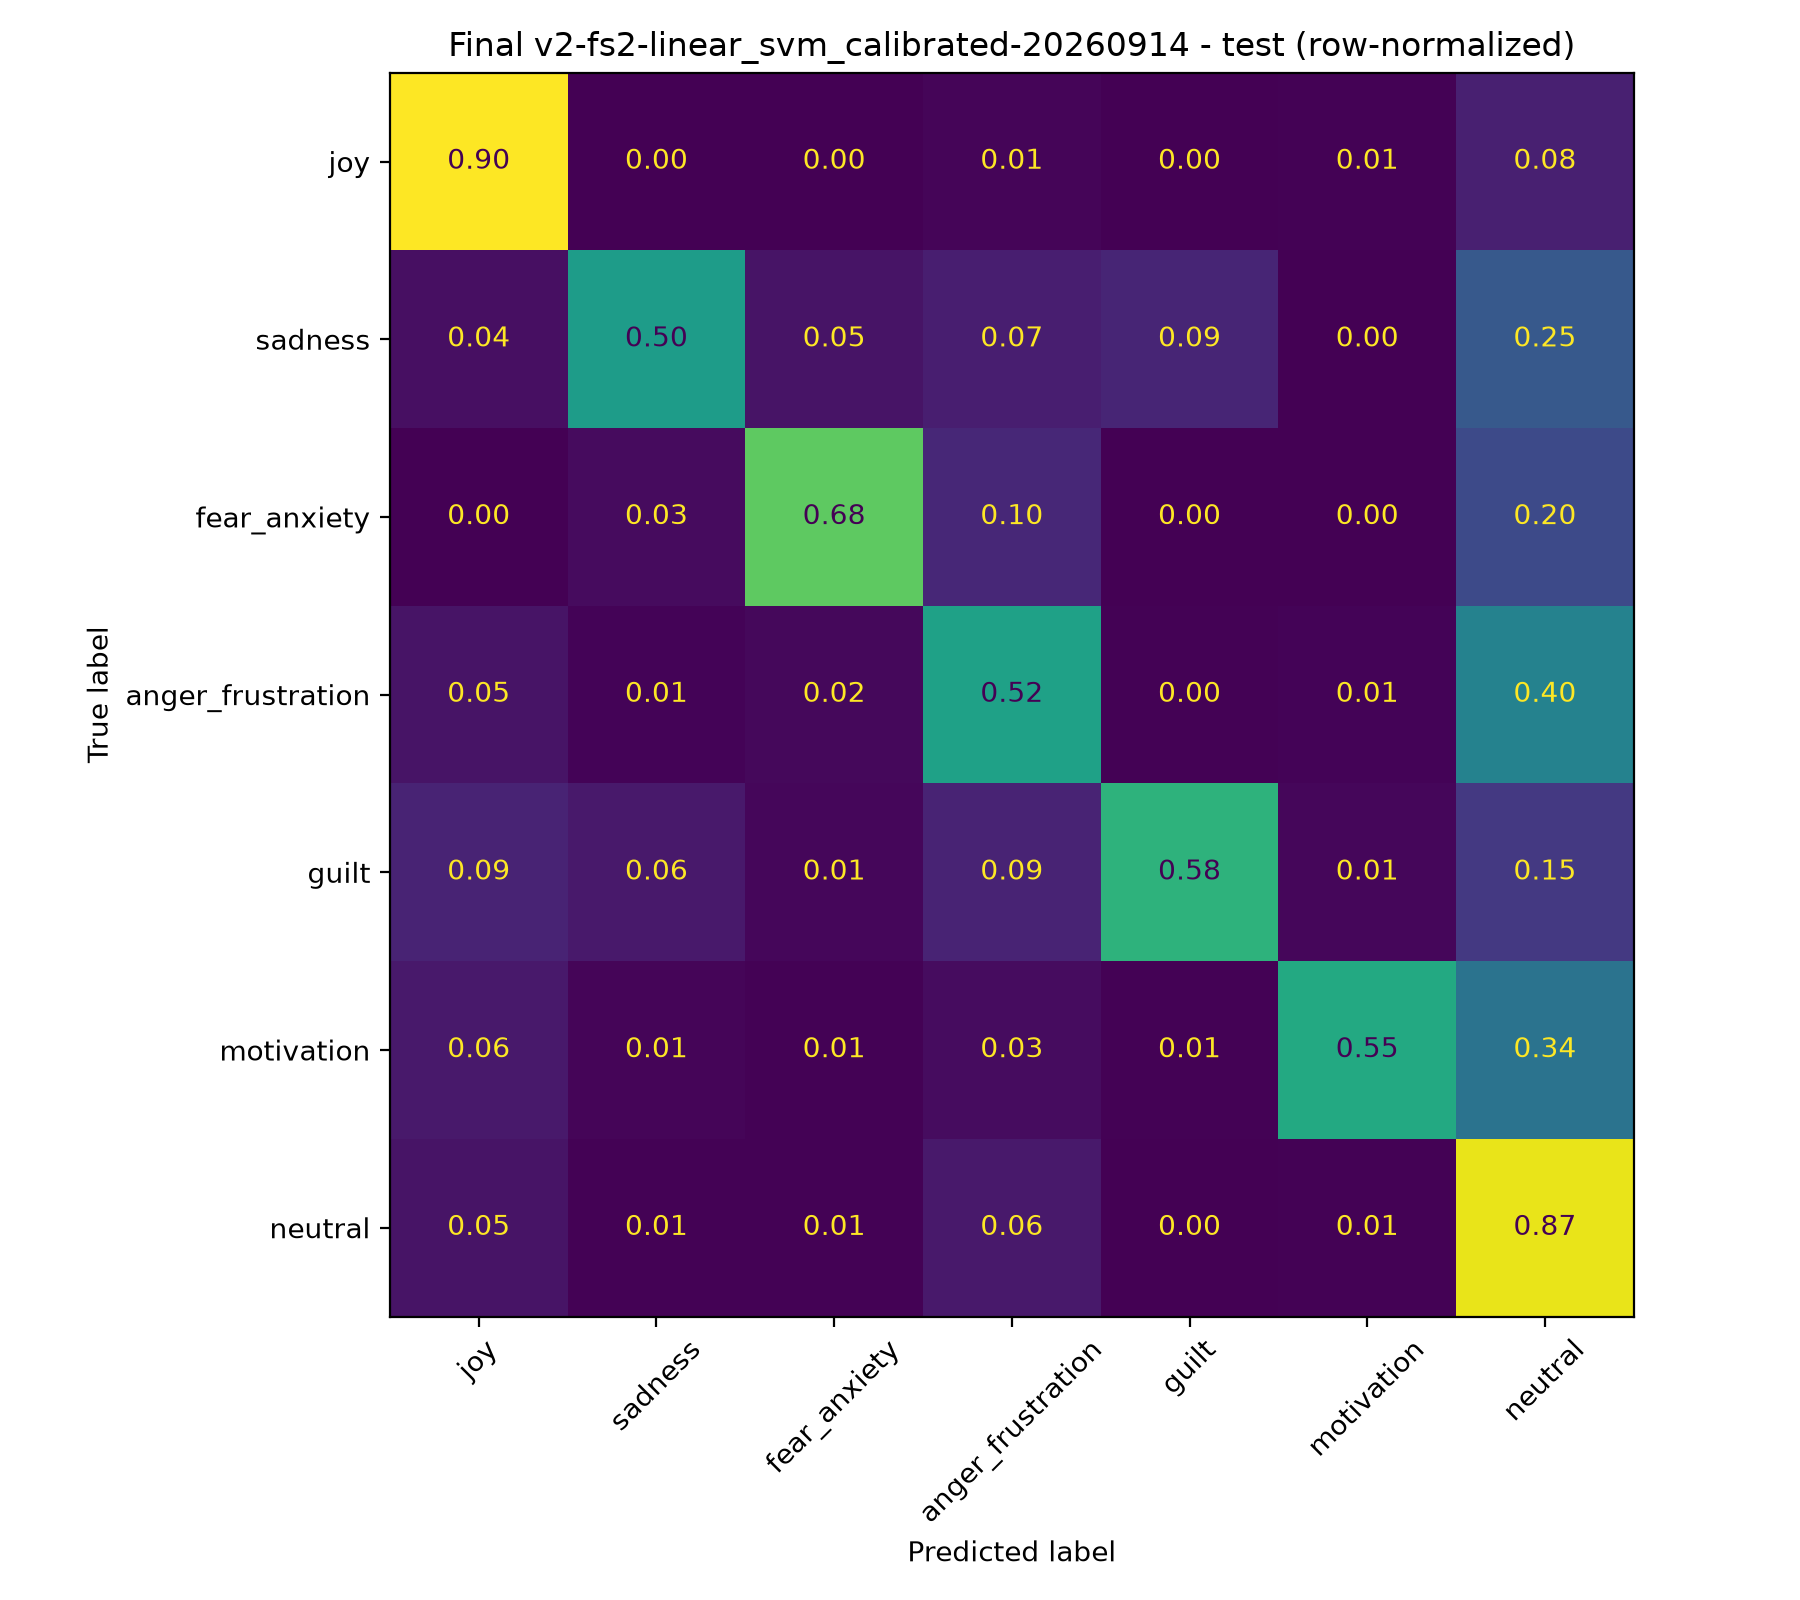

In [6]:
for path in sorted(config.FIGURES.glob("confusion_matrix_*_normalized.png")):
    print(path.name)
    display(Image(filename=str(path), width=560))